# 🐸 Boiling Frog Effect: Semantic Drift in Iterative LLM Paraphrasing

## PADBen Semantic Drift Analysis Pipeline

**Research Question:** Do individual paraphrase iterations appear semantically "safe" while cumulative drift silently crosses dangerous thresholds?

**Pipeline Architecture:**
```
[Extract] → [Validate] → [Profile] → [Transform] → [Compute] → [Verify] → [Analyze] → [Export]
   JSON      Pydantic     Quality     Cleaning     Metrics     Sanity      Boiling     Results
   Load      Schema       Report      & Filter     (cached)    Checks      Frog        & Logs
```

**Dataset:** PADBen `data.json` — 16,233 aligned text records (6 types per record) 

---
## Section 0: Configuration & Environment Setup

All tunable parameters are centralized here. Reproducibility is enforced via seed-setting across all random generators.

In [1]:
# ============================================================================
# 0A: INSTALL DEPENDENCIES (run once)
# ============================================================================
%pip install sentence-transformers nltk rouge-score bert-score scipy scikit-learn seaborn tqdm python-Levenshtein pydantic ftfy watermark --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================================
# 0B: IMPORTS
# ============================================================================
import json
import re
import os
import sys
import time
import hashlib
import logging
import warnings
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Any, Optional, Tuple

# Data handling
import pandas as pd
import numpy as np

# Validation
from pydantic import BaseModel, Field, field_validator, model_validator

# NLP metrics
from sentence_transformers import SentenceTransformer
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from bert_score import score as bert_score_compute
from scipy.spatial.distance import euclidean, cosine
from scipy.stats import spearmanr, pearsonr, iqr
from sklearn.preprocessing import MinMaxScaler
import Levenshtein as lev_module

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm.auto import tqdm
import nltk
import torch
import gc

# Text cleaning
try:
    import ftfy
    FTFY_AVAILABLE = True
except ImportError:
    FTFY_AVAILABLE = False
    print("⚠️ ftfy not installed — encoding checks will be skipped")

warnings.filterwarnings('ignore')
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✅ All imports successful")

✅ All imports successful


In [3]:
# ============================================================================
# 0C: PIPELINE CONFIGURATION (dataclass — all params in one place)
# ============================================================================
@dataclass
class PipelineConfig:
    """Central configuration for the semantic drift analysis pipeline."""
    # --- Paths ---
    data_path: str = './data.json'          
    output_dir: str = './outputs'
    cache_dir: str = './cache'
    log_dir: str = './logs'

    # --- Column names in data.json ---
    col_type1: str = 'human_original_text(type1)'
    col_type2: str = 'llm_generated_text(type2)'
    col_type3: str = 'human_paraphrased_text(type3)'
    col_type4: str = 'llm_paraphrased_original_text(type4)-prompt-based'
    col_type5_1st: str = 'llm_paraphrased_generated_text(type5)-1st'
    col_type5_3rd: str = 'llm_paraphrased_generated_text(type5)-3rd'

    # --- Model ---
    sbert_model: str = 'all-mpnet-base-v2'
    sbert_batch_size: int = 64
    bertscore_model: str = 'bert-base-uncased'
    bertscore_batch_size: int = 256

    # --- Composite SDS Weights ---
    weight_sbert: float = 0.6
    weight_meteor: float = 0.2
    weight_rouge: float = 0.2

    # --- Thresholds ---
    parascore_threshold: float = 0.35     # γ from Shen et al., EMNLP 2022
    low_med_threshold: float = 0.35
    med_high_threshold: float = 0.45

    # --- Quality gates ---
    min_completeness_pct: float = 95.0    # Halt if any column < this %
    max_duplicate_pct: float = 5.0        # Warn if duplicates exceed this %
    min_token_length: int = 3             # Flag texts shorter than this
    max_token_length: int = 500           # Flag texts longer than this

    # --- Reproducibility ---
    seed: int = 42

    # --- Runtime ---
    device: str = 'auto'                  # 'auto', 'cuda', 'cpu'

    def __post_init__(self):
        for d in [self.output_dir, self.cache_dir, self.log_dir]:
            Path(d).mkdir(parents=True, exist_ok=True)


CFG = PipelineConfig()
print("✅ Pipeline configuration initialized")
print(f"   Data path:  {CFG.data_path}")
print(f"   SBERT model: {CFG.sbert_model}")
print(f"   SDS weights: SBERT={CFG.weight_sbert}, METEOR={CFG.weight_meteor}, ROUGE={CFG.weight_rouge}")
print(f"   ParaScore γ: {CFG.parascore_threshold}")
print(f"   Seed:        {CFG.seed}")

✅ Pipeline configuration initialized
   Data path:  ./data.json
   SBERT model: all-mpnet-base-v2
   SDS weights: SBERT=0.6, METEOR=0.2, ROUGE=0.2
   ParaScore γ: 0.35
   Seed:        42


In [4]:
# ============================================================================
# 0D: SEED SETTING & DEVICE DETECTION
# ============================================================================
import random

def set_all_seeds(seed: int):
    """Set seeds across all frameworks for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_all_seeds(CFG.seed)

# Device detection
if CFG.device == 'auto':
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
else:
    DEVICE = CFG.device

print(f"✅ Seeds set to {CFG.seed}")
print(f"✅ Device: {DEVICE}", end="")
if DEVICE == 'cuda':
    print(f" — {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
else:
    print()

✅ Seeds set to 42
✅ Device: cuda — NVIDIA GeForce RTX 4060 Laptop GPU (8.6 GB)


In [5]:
# ============================================================================
# 0E: LOGGING SETUP
# ============================================================================
def setup_logger(name: str, log_dir: str) -> logging.Logger:
    """Configure pipeline logger with file + console output."""
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    logger.handlers = []  # Reset

    fmt = logging.Formatter('%(asctime)s | %(levelname)-7s | %(message)s', datefmt='%H:%M:%S')

    # Console handler
    ch = logging.StreamHandler()
    ch.setFormatter(fmt)
    logger.addHandler(ch)

    # File handler
    fh = logging.FileHandler(Path(log_dir) / f'pipeline_{time.strftime("%Y%m%d_%H%M%S")}.log')
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    return logger

log = setup_logger('boiling_frog', CFG.log_dir)
log.info("Pipeline logger initialized")

# Visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams.update({'figure.figsize': (14, 10), 'font.size': 11, 'figure.dpi': 100})

19:12:45 | INFO    | Pipeline logger initialized


---
## Section 1: Data Ingestion & Schema Validation (Extract + Validate)

We use **Pydantic** to enforce a data contract on every JSON record. Any record that fails validation is logged and quarantined — not silently dropped.

In [6]:
# ============================================================================
# 1A: PYDANTIC SCHEMA — Data Contract for PADBen Records
# ============================================================================
class PADBenRecord(BaseModel):
    """Schema contract for a single PADBen data record.
    
    Enforces:
      - idx is non-negative integer
      - dataset_source is one of known sources
      - All 6 text fields are non-empty strings with min length
    """
    idx: int = Field(ge=0, description="Record index, must be non-negative")
    dataset_source: str = Field(description="Source dataset: mrpc, paws, or hlpc")

    # The 6 text type columns
    type1: str = Field(alias='human_original_text(type1)', min_length=1)
    type2: str = Field(alias='llm_generated_text(type2)', min_length=1)
    type3: str = Field(alias='human_paraphrased_text(type3)', min_length=1)
    type4: str = Field(alias='llm_paraphrased_original_text(type4)-prompt-based', min_length=1)
    type5_1st: str = Field(alias='llm_paraphrased_generated_text(type5)-1st', min_length=1)
    type5_3rd: str = Field(alias='llm_paraphrased_generated_text(type5)-3rd', min_length=1)

    model_config = {"populate_by_name": True}

    @field_validator('dataset_source')
    @classmethod
    def validate_source(cls, v):
        allowed = {'mrpc', 'paws', 'hlpc'}
        if v.lower() not in allowed:
            raise ValueError(f"Unknown dataset_source '{v}'. Expected one of {allowed}")
        return v.lower()

    @field_validator('type1', 'type2', 'type3', 'type4', 'type5_1st', 'type5_3rd')
    @classmethod
    def validate_not_whitespace(cls, v, info):
        if not v.strip():
            raise ValueError(f"Field '{info.field_name}' is whitespace-only")
        return v.strip()

print("✅ Pydantic schema defined: PADBenRecord")

✅ Pydantic schema defined: PADBenRecord


In [7]:
# ============================================================================
# 1B: EXTRACT & VALIDATE
# ============================================================================
pipeline_start = time.time()
log.info(f"Loading data from {CFG.data_path}")

with open(CFG.data_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

log.info(f"Raw JSON loaded: {len(raw_data)} records")

# Validate each record
valid_records = []
invalid_records = []

for i, record in enumerate(tqdm(raw_data, desc="Validating records")):
    try:
        validated = PADBenRecord(**record)
        valid_records.append(record)  # Keep original dict for DataFrame
    except Exception as e:
        invalid_records.append({'index': i, 'idx': record.get('idx', '?'), 'error': str(e)})

# Validation report
log.info(f"Validation complete: {len(valid_records)} valid, {len(invalid_records)} invalid")

if invalid_records:
    log.warning(f"⚠️ {len(invalid_records)} records failed validation:")
    invalid_df = pd.DataFrame(invalid_records)
    invalid_df.to_csv(Path(CFG.output_dir) / 'validation_failures.csv', index=False)
    for row in invalid_records[:5]:
        log.warning(f"   idx={row['idx']}: {row['error'][:100]}")
    if len(invalid_records) > 5:
        log.warning(f"   ... and {len(invalid_records) - 5} more (see validation_failures.csv)")
else:
    log.info("✅ All records passed schema validation — zero failures")

# Quality gate: halt if too many failures
failure_pct = len(invalid_records) / len(raw_data) * 100
if failure_pct > 5.0:
    raise RuntimeError(f"🛑 PIPELINE HALTED: {failure_pct:.1f}% records failed validation (threshold: 5%)")

# Build DataFrame from valid records only
df = pd.DataFrame(valid_records)

# Create standardized short column names for analysis
df['Type_1'] = df[CFG.col_type1]
df['Type_2'] = df[CFG.col_type2]
df['Type_3'] = df[CFG.col_type3]
df['Type_4'] = df[CFG.col_type4]
df['Type_5_1st'] = df[CFG.col_type5_1st]
df['Type_5_3rd'] = df[CFG.col_type5_3rd]

# Compute data fingerprint for cache invalidation
data_hash = hashlib.md5(json.dumps(valid_records, sort_keys=True).encode()).hexdigest()[:12]
log.info(f"Data fingerprint: {data_hash}")

print(f"\n{'='*60}")
print(f"📊 INGESTION SUMMARY")
print(f"{'='*60}")
print(f"   Raw records:      {len(raw_data):,}")
print(f"   Valid records:    {len(valid_records):,}")
print(f"   Invalid records:  {len(invalid_records):,}")
print(f"   Failure rate:     {failure_pct:.2f}%")
print(f"   Data fingerprint: {data_hash}")
print(f"   Sources: {df['dataset_source'].value_counts().to_dict()}")

19:12:45 | INFO    | Loading data from ./data.json
19:12:45 | INFO    | Raw JSON loaded: 16233 records


Validating records:   0%|          | 0/16233 [00:00<?, ?it/s]

19:12:46 | INFO    | Validation complete: 16233 valid, 0 invalid
19:12:46 | INFO    | ✅ All records passed schema validation — zero failures
19:12:46 | INFO    | Data fingerprint: d5938717a66c



📊 INGESTION SUMMARY
   Raw records:      16,233
   Valid records:    16,233
   Invalid records:  0
   Failure rate:     0.00%
   Data fingerprint: d5938717a66c
   Sources: {'paws': 12103, 'mrpc': 3750, 'hlpc': 380}


---
## Section 2: Data Profiling & Quality Report

Automated quality assessment across 5 dimensions: **completeness, uniqueness, distribution, encoding, and cross-column consistency**. This report doubles as a methods-section table for the paper.

In [8]:
# ============================================================================
# 2A: COMPLETENESS & BASIC STATS
# ============================================================================
log.info("Running data quality profiling...")

def tokenize(text):
    """Simple whitespace+punctuation tokenizer."""
    return re.findall(r'\w+', str(text).lower())

type_cols = {
    'Type_1': 'Human Original',
    'Type_2': 'LLM Generated',
    'Type_3': 'Human Paraphrased',
    'Type_4': 'LLM Paraphrased',
    'Type_5_1st': 'LLM Iter-1',
    'Type_5_3rd': 'LLM Iter-3'
}

quality_rows = []
for col, label in type_cols.items():
    texts = df[col]
    token_lengths = texts.apply(lambda x: len(tokenize(x)))

    non_null = texts.notna().sum()
    non_empty = texts.apply(lambda x: bool(str(x).strip())).sum()
    completeness = non_empty / len(df) * 100

    # Exact duplicates within this column
    n_dupes = texts.duplicated().sum()

    # Short text detection
    n_short = (token_lengths < CFG.min_token_length).sum()
    n_long = (token_lengths > CFG.max_token_length).sum()

    # Encoding check
    n_encoding_issues = 0
    if FTFY_AVAILABLE:
        for t in texts:
            if ftfy.fix_text(str(t)) != str(t):
                n_encoding_issues += 1

    quality_rows.append({
        'Text Type': label,
        'Column': col,
        'Completeness (%)': round(completeness, 2),
        'Duplicates': n_dupes,
        'Mean Tokens': round(token_lengths.mean(), 1),
        'Median Tokens': round(token_lengths.median(), 1),
        'Min Tokens': token_lengths.min(),
        'Max Tokens': token_lengths.max(),
        'Std Tokens': round(token_lengths.std(), 1),
        'Short (<3)': n_short,
        'Long (>500)': n_long,
        'Encoding Issues': n_encoding_issues
    })

quality_df = pd.DataFrame(quality_rows)

# Display
print(f"{'='*60}")
print(f"📋 DATA QUALITY REPORT ({len(df):,} records)")
print(f"{'='*60}")
print(quality_df[['Text Type', 'Completeness (%)', 'Duplicates', 'Mean Tokens',
                   'Median Tokens', 'Short (<3)', 'Encoding Issues']].to_string(index=False))

# Quality gate: completeness
for _, row in quality_df.iterrows():
    if row['Completeness (%)'] < CFG.min_completeness_pct:
        log.error(f"🛑 QUALITY GATE FAILED: {row['Text Type']} completeness = {row['Completeness (%)']}%")
        raise RuntimeError(f"Completeness below threshold for {row['Text Type']}")

log.info("✅ All quality gates passed")

# Save quality report
quality_df.to_csv(Path(CFG.output_dir) / 'data_quality_report.csv', index=False)

19:12:46 | INFO    | Running data quality profiling...
19:12:48 | INFO    | ✅ All quality gates passed


📋 DATA QUALITY REPORT (16,233 records)
        Text Type  Completeness (%)  Duplicates  Mean Tokens  Median Tokens  Short (<3)  Encoding Issues
   Human Original             100.0           0         20.8           19.0           0               82
    LLM Generated             100.0           0         20.2           18.0           0               59
Human Paraphrased             100.0         191         18.8           19.0           0               70
  LLM Paraphrased             100.0           1         18.7           17.0           0               11
       LLM Iter-1             100.0           0         18.7           16.0           0               37
       LLM Iter-3             100.0           0         18.2           15.0           1               29


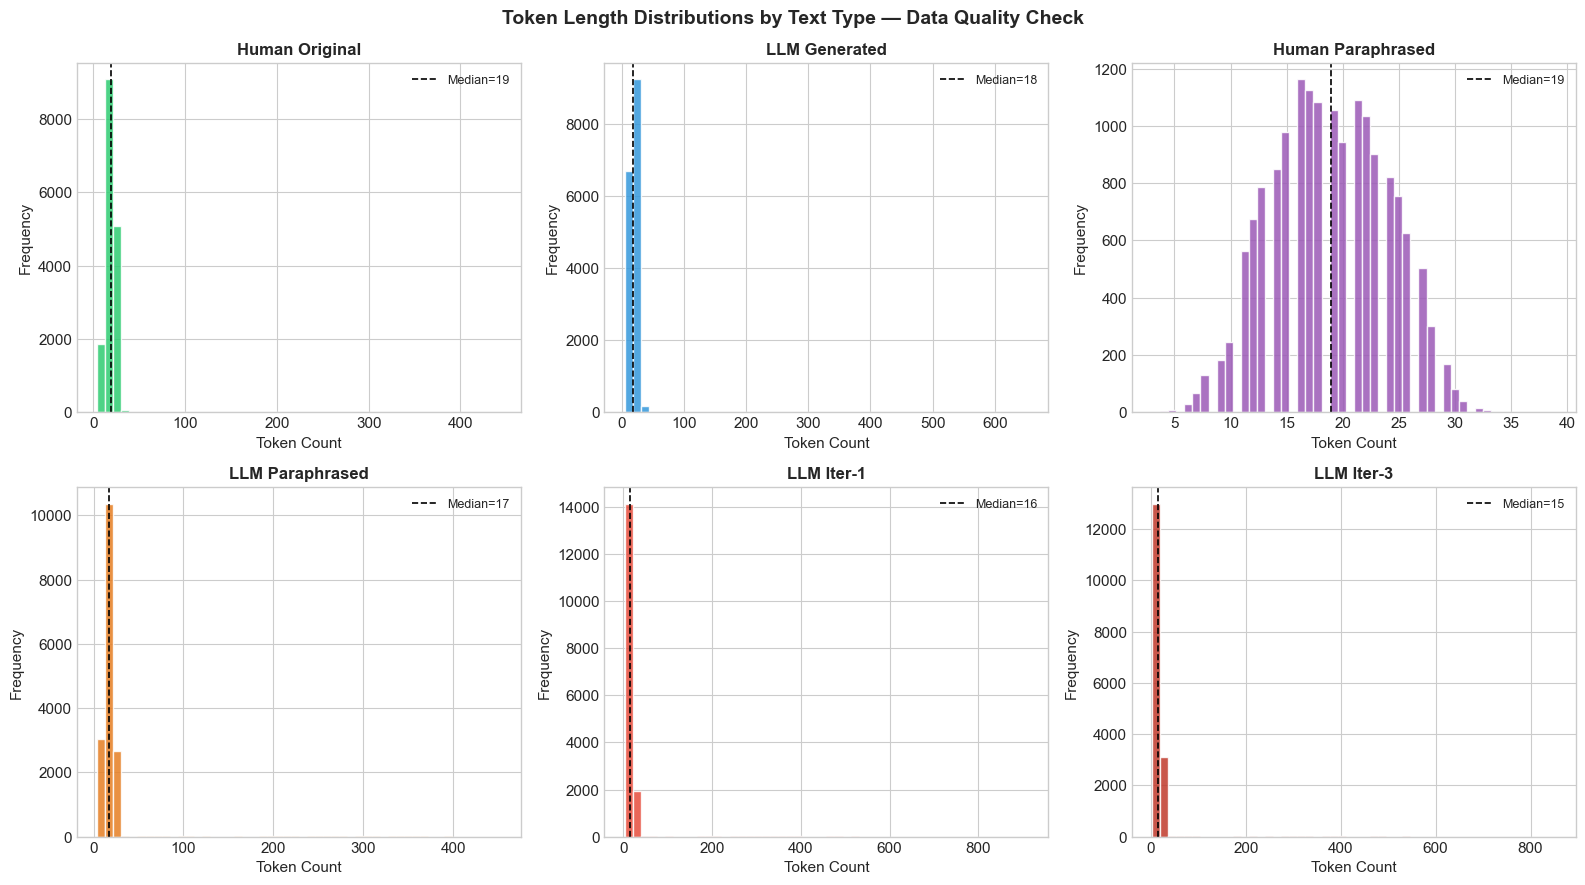

19:12:50 | INFO    | Saved: fig_token_distributions.png


In [9]:
# ============================================================================
# 2B: TOKEN LENGTH DISTRIBUTIONS — Visual QA
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#e74c3c', '#c0392b']

for i, (col, label) in enumerate(type_cols.items()):
    token_lengths = df[col].apply(lambda x: len(tokenize(x)))
    axes[i].hist(token_lengths, bins=50, edgecolor='white', alpha=0.85, color=colors[i])
    axes[i].axvline(token_lengths.median(), color='black', linestyle='--', linewidth=1.2, label=f'Median={token_lengths.median():.0f}')
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Token Count')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

fig.suptitle('Token Length Distributions by Text Type — Data Quality Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_token_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
log.info("Saved: fig_token_distributions.png")

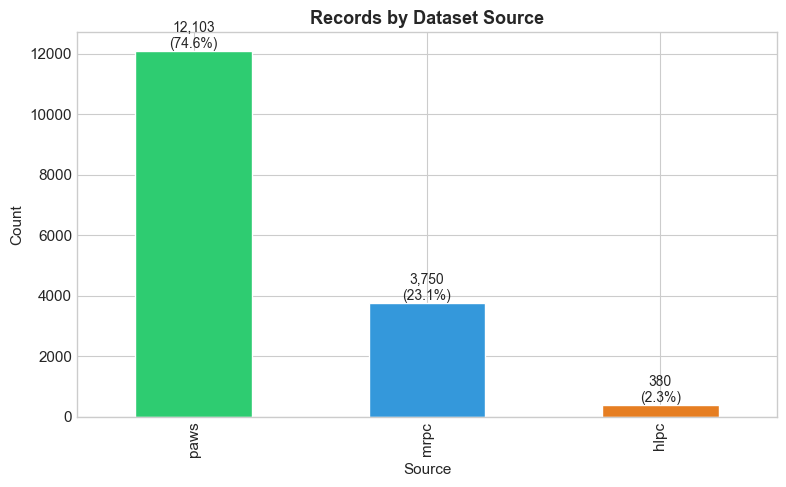

19:12:50 | INFO    | Saved: fig_source_distribution.png


In [10]:
# ============================================================================
# 2C: DATASET SOURCE DISTRIBUTION
# ============================================================================
source_counts = df['dataset_source'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
source_counts.plot(kind='bar', color=['#2ecc71', '#3498db', '#e67e22'], edgecolor='white', ax=ax)
ax.set_title('Records by Dataset Source', fontsize=13, fontweight='bold')
ax.set_xlabel('Source')
ax.set_ylabel('Count')
for i, (src, cnt) in enumerate(source_counts.items()):
    ax.text(i, cnt + 100, f'{cnt:,}\n({cnt/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_source_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
log.info("Saved: fig_source_distribution.png")

In [11]:
# ============================================================================
# 2D: SENTENCE LENGTH STATISTICS
# ============================================================================
# Source (Type 1) vs Paraphrase (Type 5-3rd) token-length comparison,
# plus a full breakdown across ALL 6 text types for completeness.
# ============================================================================

print(f"{'='*70}")
print("📊 SENTENCE LENGTH STATISTICS (for Paper Table 1)")
print(f"{'='*70}")

# Compute token lengths for all types
length_stats = {}
for col, label in type_cols.items():
    tokens = df[col].apply(lambda x: len(tokenize(x)))
    length_stats[label] = {
        'Mean': round(tokens.mean(), 2),
        'Std. Dev.': round(tokens.std(), 2),
        'Min': int(tokens.min()),
        'Median': round(tokens.median(), 1),
        'Max': int(tokens.max()),
        'n': len(tokens)
    }

# ── Full breakdown table (all 6 types) ──
print("\n📋 Full Token-Length Statistics (all text types):")
print(f"{'='*70}")

stats_df = pd.DataFrame(length_stats).T
stats_df.index.name = 'Text Type'
print(stats_df[['Mean', 'Std. Dev.', 'Min', 'Median', 'Max', 'n']].to_string())

# ── Paper Table 1: Source vs Paraphrase (Type 1 vs Type 5-3rd) ──
source_tokens = df['Type_1'].apply(lambda x: len(tokenize(x)))
para_tokens = df['Type_5_3rd'].apply(lambda x: len(tokenize(x)))

table1_data = {
    'Metric': ['Mean', 'Std. Dev.', 'Min', 'Median', 'Max'],
    'Source (T1)': [
        round(source_tokens.mean(), 2),
        round(source_tokens.std(), 2),
        int(source_tokens.min()),
        round(source_tokens.median(), 1),
        int(source_tokens.max())
    ],
    'Paraphrase (T5-3rd)': [
        round(para_tokens.mean(), 2),
        round(para_tokens.std(), 2),
        int(para_tokens.min()),
        round(para_tokens.median(), 1),
        int(para_tokens.max())
    ],
}

table1_df = pd.DataFrame(table1_data)
table1_df['Delta'] = [
    round(para_tokens.mean() - source_tokens.mean(), 2),
    round(para_tokens.std() - source_tokens.std(), 2),
    int(para_tokens.min()) - int(source_tokens.min()),
    round(para_tokens.median() - source_tokens.median(), 1),
    int(para_tokens.max()) - int(source_tokens.max())
]

print(f"\n{'='*70}")
print("📋 PAPER TABLE 1: Source vs Paraphrase Length (Type 1 vs Type 5-3rd)")
print(f"{'='*70}")
print(table1_df.to_string(index=False))

# ── Also compute for the iterative chain (T2 → T5-1st → T5-3rd) ──
t2_tokens = df['Type_2'].apply(lambda x: len(tokenize(x)))
t5_1st_tokens = df['Type_5_1st'].apply(lambda x: len(tokenize(x)))

chain_data = {
    'Stage': ['Type 1 (Human)', 'Type 2 (LLM Gen)', 'Type 3 (Human Para)',
              'Type 4 (LLM Para)', 'Type 5-1st', 'Type 5-3rd'],
    'Mean Tokens': [
        round(source_tokens.mean(), 2), round(t2_tokens.mean(), 2),
        round(df['Type_3'].apply(lambda x: len(tokenize(x))).mean(), 2),
        round(df['Type_4'].apply(lambda x: len(tokenize(x))).mean(), 2),
        round(t5_1st_tokens.mean(), 2), round(para_tokens.mean(), 2)
    ],
    'Median Tokens': [
        round(source_tokens.median(), 1), round(t2_tokens.median(), 1),
        round(df['Type_3'].apply(lambda x: len(tokenize(x))).median(), 1),
        round(df['Type_4'].apply(lambda x: len(tokenize(x))).median(), 1),
        round(t5_1st_tokens.median(), 1), round(para_tokens.median(), 1)
    ],
}

chain_df = pd.DataFrame(chain_data)
print(f"\n{'='*70}")
print("📋 TOKEN LENGTH ACROSS FULL CHAIN")
print(f"{'='*70}")
print(chain_df.to_string(index=False))

# ── Key observation ──
delta_mean = round(para_tokens.mean() - source_tokens.mean(), 2)
direction = "shorter" if delta_mean < 0 else "longer" if delta_mean > 0 else "comparable"

print(f"\n{'='*70}")
print("📝 KEY OBSERVATION (copy to paper):")
print(f"{'='*70}")
print(f"   On average, paraphrases are {direction} than sources")
print(f"   by approximately {abs(delta_mean):.1f} tokens (Source mean: {source_tokens.mean():.2f},")
print(f"   Paraphrase mean: {para_tokens.mean():.2f}).")
print("   Iterative paraphrasing shows progressive shortening:")
print(f"   T1({source_tokens.mean():.1f}) → T2({t2_tokens.mean():.1f}) → T5-1st({t5_1st_tokens.mean():.1f}) → T5-3rd({para_tokens.mean():.1f})")

# ── Export for paper ──
table1_df.to_csv(Path(CFG.output_dir) / 'paper_table1_length_stats.csv', index=False)
chain_df.to_csv(Path(CFG.output_dir) / 'paper_chain_length_stats.csv', index=False)
stats_df.to_csv(Path(CFG.output_dir) / 'paper_all_type_length_stats.csv')
log.info("Exported: paper_table1_length_stats.csv, paper_chain_length_stats.csv, paper_all_type_length_stats.csv")

# ── LaTeX-ready output for Aryan ──
print(f"\n{'='*70}")
print("📋 LATEX-READY TABLE (copy-paste into paper):")
print(f"{'='*70}")
print(r"""
\begin{table}[h]
  \caption{Sentence-length statistics on updated PADBEN (""" + f"{len(df):,}" + r""" records).}
  \label{tab:length_stats_updated}
  \centering
  \begin{tabular}{@{}lccc@{}}
    \toprule
    Metric & Source & Paraphrase & Delta \\
    \midrule""")
for _, row in table1_df.iterrows():
    src_val = row['Source (T1)']
    para_val = row['Paraphrase (T5-3rd)']
    delta_val = row['Delta']
    # Format: integers for min/max, floats for others
    if row['Metric'] in ['Min', 'Max']:
        print(f"    {row['Metric']} & {int(src_val)} & {int(para_val)} & {int(delta_val)} \\\\")
    else:
        print(f"    {row['Metric']} & {src_val:.2f} & {para_val:.2f} & {delta_val:+.2f} \\\\")
print(r"""    \bottomrule
  \end{tabular}
\end{table}""")

📊 SENTENCE LENGTH STATISTICS (for Paper Table 1)

📋 Full Token-Length Statistics (all text types):
                    Mean  Std. Dev.  Min  Median    Max        n
Text Type                                                       
Human Original     20.84      23.89  4.0    19.0  444.0  16233.0
LLM Generated      20.20      29.88  4.0    18.0  654.0  16233.0
Human Paraphrased  18.83       5.10  3.0    19.0   39.0  16233.0
LLM Paraphrased    18.70      22.91  4.0    17.0  453.0  16233.0
LLM Iter-1         18.68      31.14  3.0    16.0  912.0  16233.0
LLM Iter-3         18.24      31.85  2.0    15.0  853.0  16233.0

📋 PAPER TABLE 1: Source vs Paraphrase Length (Type 1 vs Type 5-3rd)
   Metric  Source (T1)  Paraphrase (T5-3rd)  Delta
     Mean        20.84                18.24  -2.60
Std. Dev.        23.89                31.85   7.95
      Min         4.00                 2.00  -2.00
   Median        19.00                15.00  -4.00
      Max       444.00               853.00 409.00


19:12:51 | INFO    | Exported: paper_table1_length_stats.csv, paper_chain_length_stats.csv, paper_all_type_length_stats.csv



📋 TOKEN LENGTH ACROSS FULL CHAIN
              Stage  Mean Tokens  Median Tokens
     Type 1 (Human)        20.84           19.0
   Type 2 (LLM Gen)        20.20           18.0
Type 3 (Human Para)        18.83           19.0
  Type 4 (LLM Para)        18.70           17.0
         Type 5-1st        18.68           16.0
         Type 5-3rd        18.24           15.0

📝 KEY OBSERVATION (copy to paper):
   On average, paraphrases are shorter than sources
   by approximately 2.6 tokens (Source mean: 20.84,
   Paraphrase mean: 18.24).
   Iterative paraphrasing shows progressive shortening:
   T1(20.8) → T2(20.2) → T5-1st(18.7) → T5-3rd(18.2)

📋 LATEX-READY TABLE (copy-paste into paper):

\begin{table}[h]
  \caption{Sentence-length statistics on updated PADBEN (16,233 records).}
  \label{tab:length_stats_updated}
  \centering
  \begin{tabular}{@{}lccc@{}}
    \toprule
    Metric & Source & Paraphrase & Delta \\
    \midrule
    Mean & 20.84 & 18.24 & -2.60 \\
    Std. Dev. & 23.89 & 31.85 

---
## Section 3: Preprocessing & Cleaning

Minimal cleaning to preserve original data fidelity while removing edge cases that would corrupt metric computation.

In [12]:
# ============================================================================
# 3: PREPROCESSING
# ============================================================================
log.info("Preprocessing...")

n_before = len(df)

# 3a: Fix encoding issues (if ftfy available)
if FTFY_AVAILABLE:
    for col in type_cols.keys():
        df[col] = df[col].apply(lambda x: ftfy.fix_text(str(x)))
    log.info("Applied ftfy encoding fixes")

# 3b: Strip extra whitespace
for col in type_cols.keys():
    df[col] = df[col].apply(lambda x: ' '.join(str(x).split()))

# 3c: Remove records where any text field is empty after cleaning
mask_valid = pd.Series(True, index=df.index)
for col in type_cols.keys():
    mask_valid &= df[col].apply(lambda x: len(str(x).strip()) > 0)

df = df[mask_valid].reset_index(drop=True)
n_after = len(df)

log.info(f"Preprocessing: {n_before} → {n_after} records ({n_before - n_after} removed)")
print(f"✅ Preprocessing complete: {n_after:,} records ready for analysis")

19:12:51 | INFO    | Preprocessing...
19:12:53 | INFO    | Applied ftfy encoding fixes
19:12:53 | INFO    | Preprocessing: 16233 → 16233 records (0 removed)


✅ Preprocessing complete: 16,233 records ready for analysis


---
## Section 4: SBERT Embedding Computation (with Caching)

Embeddings are the most expensive single computation (~2-5 min on GPU for ~97K texts). We cache them as `.npy` files keyed to the data fingerprint — subsequent runs skip this step entirely.

In [13]:
# ============================================================================
# 4: SBERT EMBEDDINGS — Compute or Load from Cache
# ============================================================================
log.info(f"Loading SBERT model: {CFG.sbert_model}")
sbert_model = SentenceTransformer(CFG.sbert_model, device=DEVICE)
log.info(f"Model loaded (dim={sbert_model.get_sentence_embedding_dimension()})")

def compute_or_load_embeddings(texts: pd.Series, label: str) -> np.ndarray:
    """Compute SBERT embeddings with disk caching."""
    cache_file = Path(CFG.cache_dir) / f'emb_{label}_{data_hash}.npy'

    if cache_file.exists():
        log.info(f"  Cache HIT: {label} — loading from {cache_file.name}")
        return np.load(cache_file)

    log.info(f"  Cache MISS: {label} — computing {len(texts):,} embeddings...")
    t0 = time.time()
    embs = sbert_model.encode(
        texts.tolist(),
        batch_size=CFG.sbert_batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
        device=DEVICE
    )
    elapsed = time.time() - t0
    np.save(cache_file, embs)
    log.info(f"  Computed & cached {label}: {embs.shape} in {elapsed:.1f}s")
    return embs

# Compute embeddings for all relevant columns
print(f"{'='*60}")
print("🔄 COMPUTING / LOADING SBERT EMBEDDINGS")
print(f"{'='*60}")

emb_type2     = compute_or_load_embeddings(df['Type_2'], 'type2')
emb_type5_1st = compute_or_load_embeddings(df['Type_5_1st'], 'type5_1st')
emb_type5_3rd = compute_or_load_embeddings(df['Type_5_3rd'], 'type5_3rd')
emb_type1     = compute_or_load_embeddings(df['Type_1'], 'type1')  # Reference anchor

print(f"\n✅ All embeddings ready — shape: {emb_type2.shape}")

19:12:53 | INFO    | Loading SBERT model: all-mpnet-base-v2
19:12:56 | INFO    | Model loaded (dim=768)
19:12:56 | INFO    |   Cache HIT: type2 — loading from emb_type2_d5938717a66c.npy
19:12:56 | INFO    |   Cache HIT: type5_1st — loading from emb_type5_1st_d5938717a66c.npy
19:12:56 | INFO    |   Cache HIT: type5_3rd — loading from emb_type5_3rd_d5938717a66c.npy
19:12:56 | INFO    |   Cache HIT: type1 — loading from emb_type1_d5938717a66c.npy


🔄 COMPUTING / LOADING SBERT EMBEDDINGS

✅ All embeddings ready — shape: (16233, 768)


---
## Section 5: Multi-Metric Drift Computation

Metrics are computed in **cost-ascending order** (Jaccard → ROUGE-L → METEOR → SBERT distance → BERTScore), with per-step checkpoints. Each metric captures a different facet of semantic drift:

| Metric | What It Captures | Type |
|--------|-----------------|------|
| Jaccard | Token overlap (bag of words) | Lexical |
| ROUGE-L | Longest common subsequence | Lexical/Structural |
| METEOR | Synonym-aware word matching | Lexical+ |
| SBERT Cosine | Deep semantic similarity | Semantic |
| BERTScore | Contextual token alignment | Semantic |

In [14]:
# ============================================================================
# 5A: METRIC HELPER FUNCTIONS
# ============================================================================
def calc_jaccard(texts1, texts2):
    scores = []
    for t1, t2 in zip(texts1, texts2):
        s1, s2 = set(tokenize(t1)), set(tokenize(t2))
        scores.append(len(s1 & s2) / max(1, len(s1 | s2)) if (s1 or s2) else 1.0)
    return np.array(scores)

def calc_rouge_l(texts1, texts2):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    return np.array([scorer.score(str(t1), str(t2))['rougeL'].fmeasure for t1, t2 in zip(texts1, texts2)])

def calc_meteor(texts1, texts2):
    scores = []
    for t1, t2 in tqdm(zip(texts1, texts2), total=len(texts1), desc="METEOR"):
        scores.append(meteor_score([tokenize(t1)], tokenize(t2)))
    return np.array(scores)

def calc_sbert_cosine(emb1, emb2):
    """Cosine similarity (not distance) between normalized embeddings."""
    return np.array([1 - cosine(e1, e2) for e1, e2 in zip(emb1, emb2)])

def calc_sbert_euclidean(emb1, emb2):
    return np.array([euclidean(e1, e2) for e1, e2 in zip(emb1, emb2)])

def calc_edit_distance(texts1, texts2):
    scores = []
    for t1, t2 in zip(texts1, texts2):
        max_len = max(len(str(t1)), len(str(t2)))
        scores.append(lev_module.distance(str(t1), str(t2)) / max_len if max_len > 0 else 0.0)
    return np.array(scores)

print("✅ Metric functions defined")

✅ Metric functions defined


In [15]:
# ============================================================================
# 5B: COMPUTE ALL METRICS PER HOP
# ============================================================================
def compute_hop_metrics(texts_ref, texts_hyp, emb_ref, emb_hyp, hop_name: str) -> dict:
    """Compute all metrics for a single hop in the paraphrase chain."""
    log.info(f"Computing metrics for {hop_name}...")
    t0 = time.time()

    ref_list = texts_ref.tolist()
    hyp_list = texts_hyp.tolist()

    metrics = {}

    # Cost-ascending order
    log.info(f"  [{hop_name}] Jaccard...")
    metrics['jaccard'] = calc_jaccard(ref_list, hyp_list)

    log.info(f"  [{hop_name}] ROUGE-L...")
    metrics['rouge_l'] = calc_rouge_l(ref_list, hyp_list)

    log.info(f"  [{hop_name}] METEOR...")
    metrics['meteor'] = calc_meteor(ref_list, hyp_list)

    log.info(f"  [{hop_name}] SBERT Cosine Similarity...")
    metrics['sbert_cosine'] = calc_sbert_cosine(emb_ref, emb_hyp)

    log.info(f"  [{hop_name}] SBERT Euclidean Distance...")
    metrics['sbert_euclid'] = calc_sbert_euclidean(emb_ref, emb_hyp)

    log.info(f"  [{hop_name}] Edit Distance...")
    metrics['edit_dist'] = calc_edit_distance(ref_list, hyp_list)

    elapsed = time.time() - t0
    log.info(f"  [{hop_name}] All metrics computed in {elapsed:.1f}s")
    return metrics

# --- HOP A: Type 2 → Type 5 (1st iteration) ---
print(f"\n{'='*60}")
print("📊 HOP A: Type 2 → Type 5 (1st iteration)")
print(f"{'='*60}")
hop_a = compute_hop_metrics(df['Type_2'], df['Type_5_1st'], emb_type2, emb_type5_1st, 'Hop_A')

# --- HOP B: Type 5 (1st) → Type 5 (3rd iteration) ---
print(f"\n{'='*60}")
print("📊 HOP B: Type 5 (1st) → Type 5 (3rd iteration)")
print(f"{'='*60}")
hop_b = compute_hop_metrics(df['Type_5_1st'], df['Type_5_3rd'], emb_type5_1st, emb_type5_3rd, 'Hop_B')

# --- END-TO-END: Type 2 → Type 5 (3rd) ---
print(f"\n{'='*60}")
print("📊 END-TO-END: Type 2 → Type 5 (3rd iteration)")
print(f"{'='*60}")
e2e = compute_hop_metrics(df['Type_2'], df['Type_5_3rd'], emb_type2, emb_type5_3rd, 'E2E')

# --- ANCHOR COMPARISON: Type 1 → Type 5 (3rd) — total drift from human original ---
print(f"\n{'='*60}")
print("📊 ANCHOR: Type 1 (Human Original) → Type 5 (3rd iteration)")
print(f"{'='*60}")
anchor = compute_hop_metrics(df['Type_1'], df['Type_5_3rd'], emb_type1, emb_type5_3rd, 'Anchor')

print("\n✅ All hop metrics computed")

19:12:57 | INFO    | Computing metrics for Hop_A...
19:12:57 | INFO    |   [Hop_A] Jaccard...



📊 HOP A: Type 2 → Type 5 (1st iteration)


19:12:57 | INFO    |   [Hop_A] ROUGE-L...
19:13:03 | INFO    |   [Hop_A] METEOR...
INFO:boiling_frog:  [Hop_A] METEOR...


METEOR:   0%|          | 0/16233 [00:00<?, ?it/s]

19:13:09 | INFO    |   [Hop_A] SBERT Cosine Similarity...
INFO:boiling_frog:  [Hop_A] SBERT Cosine Similarity...
19:13:09 | INFO    |   [Hop_A] SBERT Euclidean Distance...
INFO:boiling_frog:  [Hop_A] SBERT Euclidean Distance...
19:13:10 | INFO    |   [Hop_A] Edit Distance...
INFO:boiling_frog:  [Hop_A] Edit Distance...
19:13:10 | INFO    |   [Hop_A] All metrics computed in 13.0s
INFO:boiling_frog:  [Hop_A] All metrics computed in 13.0s
19:13:10 | INFO    | Computing metrics for Hop_B...
INFO:boiling_frog:Computing metrics for Hop_B...
19:13:10 | INFO    |   [Hop_B] Jaccard...
INFO:boiling_frog:  [Hop_B] Jaccard...
19:13:10 | INFO    |   [Hop_B] ROUGE-L...
INFO:boiling_frog:  [Hop_B] ROUGE-L...


...


📊 ANCHOR: Type 1 (Human Original) → Type 5 (3rd iteration)


19:13:37 | INFO    |   [Anchor] METEOR...
INFO:boiling_frog:  [Anchor] METEOR...


METEOR:   0%|          | 0/16233 [00:00<?, ?it/s]

19:13:44 | INFO    |   [Anchor] SBERT Cosine Similarity...
INFO:boiling_frog:  [Anchor] SBERT Cosine Similarity...
19:13:44 | INFO    |   [Anchor] SBERT Euclidean Distance...
INFO:boiling_frog:  [Anchor] SBERT Euclidean Distance...
19:13:44 | INFO    |   [Anchor] Edit Distance...
INFO:boiling_frog:  [Anchor] Edit Distance...
19:13:44 | INFO    |   [Anchor] All metrics computed in 12.5s
INFO:boiling_frog:  [Anchor] All metrics computed in 12.5s



✅ All hop metrics computed


In [16]:
# ============================================================================
# 5C: STORE METRICS IN DATAFRAME + COMPUTE COMPOSITE SDS
# ============================================================================
# Store per-hop metrics
for name, metrics in [('hop_a', hop_a), ('hop_b', hop_b), ('e2e', e2e), ('anchor', anchor)]:
    for metric, values in metrics.items():
        df[f'{metric}_{name}'] = values

# Compute normalized SDS for each hop
scaler = MinMaxScaler()

for name, metrics in [('hop_a', hop_a), ('hop_b', hop_b), ('e2e', e2e), ('anchor', anchor)]:
    raw = np.column_stack([
        metrics['sbert_euclid'],
        1 - metrics['meteor'],      # Invert: higher = more drift
        1 - metrics['rouge_l']      # Invert: higher = more drift
    ])
    raw = np.nan_to_num(raw, nan=0.5)

    if name == 'hop_a':
        normed = scaler.fit_transform(raw)  # Fit on first hop
    else:
        normed = scaler.transform(raw)      # Reuse scaler for comparability

    df[f'sbert_norm_{name}'] = normed[:, 0]
    df[f'meteor_norm_{name}'] = normed[:, 1]
    df[f'rouge_norm_{name}'] = normed[:, 2]

    df[f'SDS_{name}'] = (
        CFG.weight_sbert * normed[:, 0] +
        CFG.weight_meteor * normed[:, 1] +
        CFG.weight_rouge * normed[:, 2]
    )

print("✅ Composite SDS scores computed for all hops")
for name in ['hop_a', 'hop_b', 'e2e', 'anchor']:
    print(f"   SDS_{name}: mean={df[f'SDS_{name}'].mean():.4f}, std={df[f'SDS_{name}'].std():.4f}")

✅ Composite SDS scores computed for all hops
   SDS_hop_a: mean=0.3403, std=0.1104
   SDS_hop_b: mean=0.3211, std=0.1290
   SDS_e2e: mean=0.3980, std=0.1285
   SDS_anchor: mean=0.5914, std=0.1366


---
## Section 6: Results Validation & Sanity Checks

Catch silent computation errors before they propagate into analysis.

19:13:44 | INFO    | Running sanity checks...
INFO:boiling_frog:Running sanity checks...
19:13:44 | INFO    |   ✅ Monotonicity: E2E drift >= Hop A drift
INFO:boiling_frog:  ✅ Monotonicity: E2E drift >= Hop A drift
19:13:44 | INFO    |   ✅ Cross-metric: SBERT↔ROUGE-L correlation = 0.535 (p=0.00e+00)
INFO:boiling_frog:  ✅ Cross-metric: SBERT↔ROUGE-L correlation = 0.535 (p=0.00e+00)
19:13:44 | INFO    |   ✅ Known-pair: identical text cosine = 1.000000
INFO:boiling_frog:  ✅ Known-pair: identical text cosine = 1.000000
19:13:44 | INFO    | Saved 6 extreme drift cases to extreme_drift_cases.csv
INFO:boiling_frog:Saved 6 extreme drift cases to extreme_drift_cases.csv



🔍 SANITY CHECK RESULTS: 23/23 passed

🐸 EXTREME DRIFT DISCOVERY — Negative Cosine Cases
   ⚠️ Hop A (2→5_1st)           min= -0.0015  negative=   1 (0.01%)
   ✅ Hop B (5_1st→5_3rd)       min=  0.2551  negative=   0 (0.00%)
   ⚠️ E2E (2→5_3rd)             min= -0.0441  negative=   1 (0.01%)
   ⚠️ Anchor (1→5_3rd)          min= -0.1011  negative=   6 (0.04%)

📊 Extreme Drift Progression (negative cosine cases):
   Hop A:       1 cases
   Hop B:       0 cases
   E2E:         1 cases
   Anchor:      6 cases

🔬 WORST-CASE DRIFT EXAMPLES (for paper / presentation)

--- Extreme Case #1 (idx=15590, source=paws) ---
   Cosine Similarity: -0.1011
   Original (Type 1):  The cohesive command and influence are key factors :...
   LLM Gen (Type 2):   The cat stretched lazily in a patch of sunlight....
   After 3 itr (5_3rd):The cat sprawled out, basking in sunshine....

--- Extreme Case #2 (idx=10083, source=paws) ---
   Cosine Similarity: -0.0428
   Original (Type 1):  Sometimes it is also conveni

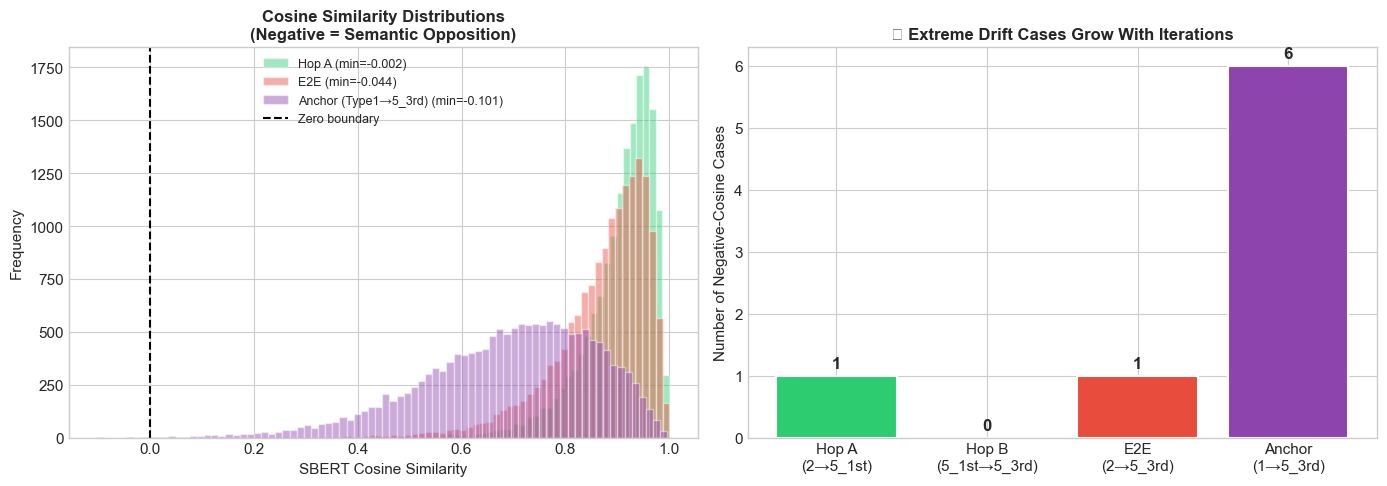

19:13:45 | INFO    | Saved: fig_extreme_drift_discovery.png
INFO:boiling_frog:Saved: fig_extreme_drift_discovery.png


In [17]:
# ============================================================================
# 6: SANITY CHECKS + EXTREME DRIFT DISCOVERY
# ============================================================================
log.info("Running sanity checks...")

checks_passed = 0
checks_total = 0

# 6a: Range assertions
# NOTE: sbert_cosine is mathematically valid in [-1, 1] — negative values
# indicate near-orthogonal embeddings (extreme semantic divergence), NOT bugs.
range_checks = {
    'sbert_cosine': (-1, 1),   # Cosine similarity: full mathematical range
    'jaccard':      (0, 1),
    'rouge_l':      (0, 1),
    'meteor':       (0, 1),
    'edit_dist':    (0, 1)
}

for metric, (lo, hi) in range_checks.items():
    for hop in ['hop_a', 'hop_b', 'e2e', 'anchor']:
        col = f'{metric}_{hop}'
        if col in df.columns:
            checks_total += 1
            vals = df[col].dropna()
            if vals.min() >= lo - 0.001 and vals.max() <= hi + 0.001:
                checks_passed += 1
            else:
                log.error(f"  ❌ RANGE VIOLATION: {col} — min={vals.min():.4f}, max={vals.max():.4f}")

# 6b: Monotonicity check — E2E drift should be >= individual hops on average
checks_total += 1
if df['SDS_e2e'].mean() >= df['SDS_hop_a'].mean():
    checks_passed += 1
    log.info("  ✅ Monotonicity: E2E drift >= Hop A drift")
else:
    log.warning("  ⚠️ Monotonicity violation: E2E < Hop A (possible normalization artifact)")

# 6c: Cross-metric correlation — SBERT cosine and ROUGE-L should correlate positively
checks_total += 1
corr, pval = spearmanr(df['sbert_cosine_e2e'], df['rouge_l_e2e'])
if corr > 0:
    checks_passed += 1
    log.info(f"  ✅ Cross-metric: SBERT↔ROUGE-L correlation = {corr:.3f} (p={pval:.2e})")
else:
    log.warning(f"  ⚠️ Unexpected negative SBERT↔ROUGE-L correlation: {corr:.3f}")

# 6d: Known-pair test — identical text should have similarity ≈ 1.0
checks_total += 1
test_cosine = 1 - cosine(emb_type2[0], emb_type2[0])
if test_cosine > 0.99:
    checks_passed += 1
    log.info(f"  ✅ Known-pair: identical text cosine = {test_cosine:.6f}")
else:
    log.error(f"  ❌ Known-pair test failed: cosine = {test_cosine:.6f}")

print(f"\n{'='*60}")
print(f"🔍 SANITY CHECK RESULTS: {checks_passed}/{checks_total} passed")
print(f"{'='*60}")

# ============================================================================
# 6e: EXTREME DRIFT DISCOVERY — Negative cosine = semantic opposition
# ============================================================================
# Negative cosine similarity means the embedding vectors point in opposing
# directions — the paraphrased text has drifted so far it's semantically
# OPPOSITE to the original. These are the most extreme cases of the
# Boiling Frog Effect and are research-worthy findings, not errors.
# ============================================================================
print(f"\n{'='*60}")
print("🐸 EXTREME DRIFT DISCOVERY — Negative Cosine Cases")
print(f"{'='*60}")

drift_summary = []
for hop, label in [('hop_a', 'Hop A (2→5_1st)'),
                   ('hop_b', 'Hop B (5_1st→5_3rd)'),
                   ('e2e',   'E2E (2→5_3rd)'),
                   ('anchor','Anchor (1→5_3rd)')]:

    col = f'sbert_cosine_{hop}'
    vals = df[col]
    n_negative = (vals < 0).sum()
    pct_negative = n_negative / len(df) * 100
    min_val = vals.min()

    drift_summary.append({
        'Hop': label,
        'Min Cosine': round(min_val, 4),
        'Negative Count': n_negative,
        'Negative %': round(pct_negative, 2),
        'Mean Cosine': round(vals.mean(), 4)
    })

    status = "⚠️" if n_negative > 0 else "✅"
    print(f"   {status} {label:<25} min={min_val:>8.4f}  negative={n_negative:>4} ({pct_negative:.2f}%)")

drift_summary_df = pd.DataFrame(drift_summary)

# Key insight: does the number of extreme cases grow with iterations?
neg_hop_a  = (df['sbert_cosine_hop_a'] < 0).sum()
neg_hop_b  = (df['sbert_cosine_hop_b'] < 0).sum()
neg_e2e    = (df['sbert_cosine_e2e'] < 0).sum()
neg_anchor = (df['sbert_cosine_anchor'] < 0).sum()

print("\n📊 Extreme Drift Progression (negative cosine cases):")
print(f"   Hop A:   {neg_hop_a:>5} cases")
print(f"   Hop B:   {neg_hop_b:>5} cases")
print(f"   E2E:     {neg_e2e:>5} cases")
print(f"   Anchor:  {neg_anchor:>5} cases")

if neg_e2e > neg_hop_a:
    print("\n   🐸 Extreme drift cases INCREASE with iterations!")
    print(f"      {neg_hop_a} → {neg_e2e} ({neg_e2e - neg_hop_a:+d} more) for E2E vs single hop")
    print(f"      {neg_hop_a} → {neg_anchor} ({neg_anchor - neg_hop_a:+d} more) for Anchor vs single hop")
    log.info(f"Extreme drift cases grow: hop_a={neg_hop_a}, e2e={neg_e2e}, anchor={neg_anchor}")

# ============================================================================
# 6f: SPOTLIGHT — Worst-case drift examples (for paper)
# ============================================================================
print(f"\n{'='*60}")
print("🔬 WORST-CASE DRIFT EXAMPLES (for paper / presentation)")
print(f"{'='*60}")

# Find the N most extreme anchor drift cases
N_EXAMPLES = 3
worst_anchor = df.nsmallest(N_EXAMPLES, 'sbert_cosine_anchor')

for rank, (_, row) in enumerate(worst_anchor.iterrows(), 1):
    print(f"\n--- Extreme Case #{rank} (idx={row['idx']}, source={row['dataset_source']}) ---")
    print(f"   Cosine Similarity: {row['sbert_cosine_anchor']:.4f}")
    print(f"   Original (Type 1):  {str(row['Type_1'])[:120]}...")
    print(f"   LLM Gen (Type 2):   {str(row['Type_2'])[:120]}...")
    print(f"   After 3 itr (5_3rd):{str(row['Type_5_3rd'])[:120]}...")

# Save extreme cases for reference
extreme_cases = df[df['sbert_cosine_anchor'] < 0][
    ['idx', 'dataset_source', 'Type_1', 'Type_2', 'Type_5_1st', 'Type_5_3rd',
     'sbert_cosine_hop_a', 'sbert_cosine_e2e', 'sbert_cosine_anchor']
].copy()

if len(extreme_cases) > 0:
    extreme_cases.to_csv(Path(CFG.output_dir) / 'extreme_drift_cases.csv', index=False)
    log.info(f"Saved {len(extreme_cases)} extreme drift cases to extreme_drift_cases.csv")
    print(f"\n💾 Saved {len(extreme_cases)} extreme drift cases → {CFG.output_dir}/extreme_drift_cases.csv")

# ============================================================================
# 6g: FIGURE — Extreme Drift Visualization
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cosine similarity distribution per hop showing negative tail
ax = axes[0]
for hop, color, label in [('hop_a', '#2ecc71', 'Hop A'),
                           ('e2e',   '#e74c3c', 'E2E'),
                           ('anchor','#8e44ad', 'Anchor (Type1→5_3rd)')]:
    vals = df[f'sbert_cosine_{hop}']
    ax.hist(vals, bins=80, alpha=0.45, color=color, label=f'{label} (min={vals.min():.3f})', edgecolor='white')

ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Zero boundary')
ax.set_xlabel('SBERT Cosine Similarity', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Cosine Similarity Distributions\n(Negative = Semantic Opposition)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Right: Negative case count progression — bar chart
ax = axes[1]
hops = ['Hop A\n(2→5_1st)', 'Hop B\n(5_1st→5_3rd)', 'E2E\n(2→5_3rd)', 'Anchor\n(1→5_3rd)']
neg_counts = [neg_hop_a, neg_hop_b, neg_e2e, neg_anchor]
bar_colors = ['#2ecc71', '#3498db', '#e74c3c', '#8e44ad']
bars = ax.bar(hops, neg_counts, color=bar_colors, edgecolor='white', linewidth=1.5)

for bar, cnt in zip(bars, neg_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(neg_counts)*0.02,
            f'{cnt}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Negative-Cosine Cases', fontsize=11)
ax.set_title('🐸 Extreme Drift Cases Grow With Iterations', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_extreme_drift_discovery.png', dpi=150, bbox_inches='tight')
plt.show()
log.info("Saved: fig_extreme_drift_discovery.png")

## Section 6.5: Generation Artifact Detection & Extreme Drift Classification

**Discovery:** Our sanity checks (Section 6e) identified records where the final paraphrased text (Type 5-3rd) has **zero lexical overlap** with both the human original (Type 1) and the LLM generation (Type 2). Manual inspection reveals these are actually **two distinct phenomena** that must be separated:

| Category | What happened | ROUGE-L vs origins | SBERT Cosine (Anchor) | Action |
|----------|--------------|-------------------|----------------------|--------|
| 🐸 **Extreme Boiling Frog** | Gradual synonym replacement erased all shared words, but meaning stayed in the same ballpark | ≈ 0 | **Positive** (> 0.1) | **Keep** — strongest evidence of subtle cumulative drift |
| 🗑️ **True Generation Artifact** | LLM hallucinated completely unrelated content | ≈ 0 | **Negative or near-zero** (≤ 0.1) | **Remove** — upstream pipeline failure, not drift |

**Why this distinction matters:** The Boiling Frog Effect is about *gradual, unnoticed* drift. Artifact #7 ("Existentialism says existence precedes essence" → "Our being shapes our identity") is a textbook Boiling Frog case — each hop is a valid paraphrase, but zero original words survive. Filtering these out would *remove our best evidence*. Meanwhile, the BYU professor → unrelated content case is a genuine pipeline failure that would corrupt our metrics.

**Dual criteria:** `ROUGE-L < 0.05` (lexical erosion) + `SBERT cosine ≤ 0.1` (semantic departure) = True Artifact. Lexical erosion alone with preserved semantics = Extreme Boiling Frog.

> Both categories are exported separately. The true generation artifacts (`generation_artifacts.csv`) represent upstream data quality issues worth investigating. The extreme Boiling Frog cases (`extreme_boiling_frog_cases.csv`) are our most compelling research findings.

19:13:45 | INFO    | Running generation artifact detection with dual-criteria classification...
INFO:boiling_frog:Running generation artifact detection with dual-criteria classification...


Checking for zero-overlap records:   0%|          | 0/16233 [00:00<?, ?it/s]

19:13:57 | INFO    | Classification: 14 zero-overlap → 13 Boiling Frog + 1 artifacts
INFO:boiling_frog:Classification: 14 zero-overlap → 13 Boiling Frog + 1 artifacts
19:13:57 | INFO    | Exported 13 extreme Boiling Frog cases → extreme_boiling_frog_cases.csv
INFO:boiling_frog:Exported 13 extreme Boiling Frog cases → extreme_boiling_frog_cases.csv
19:13:57 | INFO    | Exported 1 generation artifacts → generation_artifacts.csv
INFO:boiling_frog:Exported 1 generation artifacts → generation_artifacts.csv
19:13:57 | INFO    | Filtered: 16233 → 16232 (1 artifacts removed, 13 Boiling Frog cases preserved)
INFO:boiling_frog:Filtered: 16233 → 16232 (1 artifacts removed, 13 Boiling Frog cases preserved)
19:13:57 | INFO    | Embeddings re-indexed to match 16232 records
INFO:boiling_frog:Embeddings re-indexed to match 16232 records



🔬 DUAL-CRITERIA CLASSIFICATION RESULTS
   Total records:                 16,233
   Zero lexical overlap:          14 (0.086%)

   Classified as:
   🐸 Extreme Boiling Frog:       13  (ROUGE-L≈0, SBERT cosine > 0.1)
   🗑️  True Generation Artifact:   1  (ROUGE-L≈0, SBERT cosine ≤ 0.1)
   ✅ Normal:                      16,219

🐸 EXTREME BOILING FROG CASES — Zero words survived, meaning preserved
   These are the strongest evidence for cumulative drift:
   Every intermediate hop was a valid paraphrase, but after 3 iterations,
   NOT A SINGLE original word remains — yet the meaning is still recognizable.

--- 🐸 Boiling Frog Case #1 (idx=2673, source=mrpc) ---
   SBERT Cosine (Anchor): 0.3199  ← meaning PRESERVED despite zero word overlap
   ROUGE-L vs Type 1: 0.0000  |  vs Type 2: 0.0000  ← ZERO lexical overlap

   Type 1 (Human):    Consumers would still have to get a descrambling security card from their cable operator to plug into the set 
   Type 2 (LLM):      Consumers would still hav

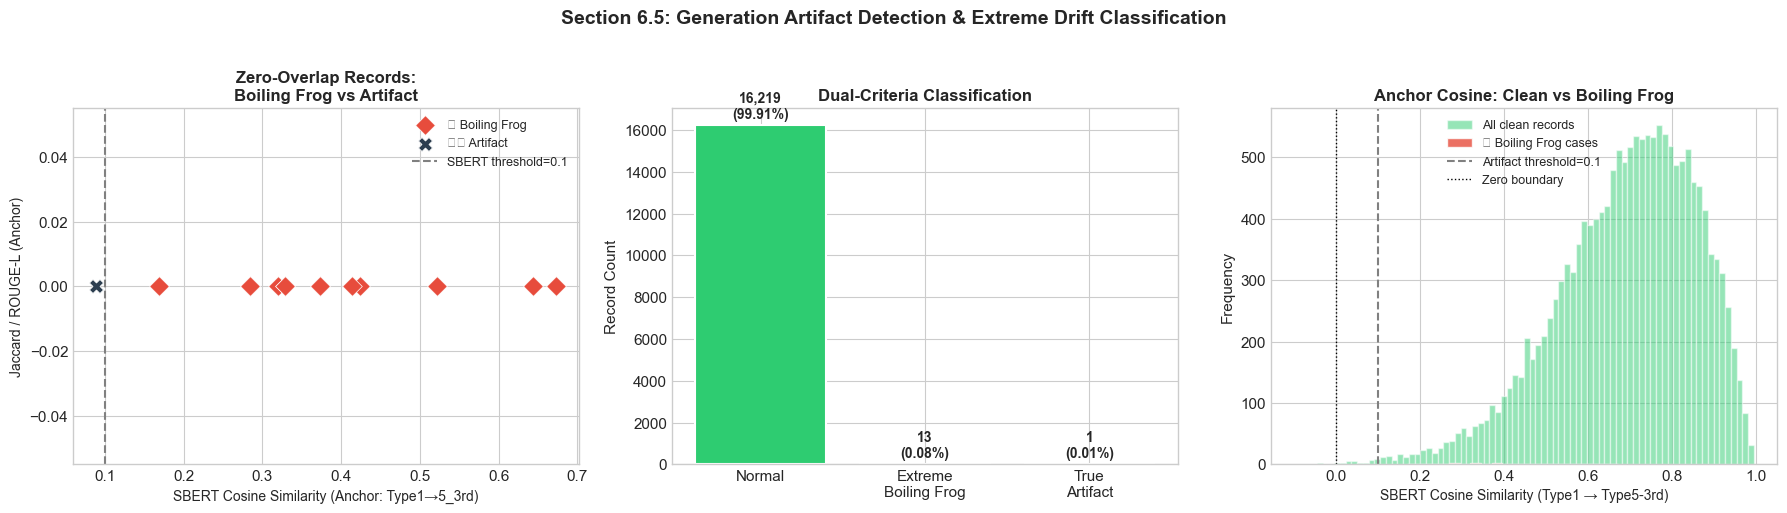

19:13:58 | INFO    | Saved: fig_artifact_classification.png
INFO:boiling_frog:Saved: fig_artifact_classification.png



SUMMARY
  • 13 'Extreme Boiling Frog' cases found — zero original words
    survived 3 iterations, yet meaning is still recognizable.
    These are our strongest evidence for cumulative lexical drift.

  • 1 true generation artifacts detected where the
    paraphrasing model hallucinated completely unrelated content.
    Exported to generation_artifacts.csv with hallucination traces.
  • All artifacts had ROUGE-L = 0.0 vs both Type 1 and Type 2,
    and SBERT cosine ≤ 0.1 indicating no semantic connection.


In [18]:
# ============================================================================
# 6.5: GENERATION ARTIFACT DETECTION & EXTREME DRIFT CLASSIFICATION
# ============================================================================
log.info("Running generation artifact detection with dual-criteria classification...")

# Step 1: Compute ROUGE-L of Type 5-3rd against BOTH Type 1 and Type 2
rouge_obj = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
ARTIFACT_ROUGE_THRESHOLD = 0.05  # Below this = zero meaningful lexical overlap
ARTIFACT_SBERT_THRESHOLD = 0.10  # Below this + zero ROUGE = true hallucination

zero_overlap_flags = []

for i in tqdm(range(len(df)), desc="Checking for zero-overlap records"):
    t1 = str(df['Type_1'].iloc[i])
    t2 = str(df['Type_2'].iloc[i])
    t5_3 = str(df['Type_5_3rd'].iloc[i])

    rouge_vs_t1 = rouge_obj.score(t1, t5_3)['rougeL'].fmeasure
    rouge_vs_t2 = rouge_obj.score(t2, t5_3)['rougeL'].fmeasure

    has_zero_overlap = (rouge_vs_t1 < ARTIFACT_ROUGE_THRESHOLD) and (rouge_vs_t2 < ARTIFACT_ROUGE_THRESHOLD)

    zero_overlap_flags.append({
        'idx': df['idx'].iloc[i],
        'rouge_t5_3rd_vs_t1': round(rouge_vs_t1, 4),
        'rouge_t5_3rd_vs_t2': round(rouge_vs_t2, 4),
        'has_zero_overlap': has_zero_overlap
    })

flag_df = pd.DataFrame(zero_overlap_flags)

# ============================================================================
# Step 2: Dual-criteria classification
# ============================================================================
# For zero-overlap records, check SBERT cosine (anchor: Type1 → Type5-3rd)
# to distinguish semantic preservation (Boiling Frog) from hallucination (Artifact)

df['has_zero_overlap'] = flag_df['has_zero_overlap'].values

zero_overlap_mask = df['has_zero_overlap']
n_zero_overlap = zero_overlap_mask.sum()

# Classify using anchor cosine similarity
df['drift_category'] = 'normal'  # Default

if n_zero_overlap > 0:
    # Extreme Boiling Frog: zero lexical overlap BUT semantic meaning preserved
    boiling_frog_mask = zero_overlap_mask & (df['sbert_cosine_anchor'] > ARTIFACT_SBERT_THRESHOLD)
    df.loc[boiling_frog_mask, 'drift_category'] = 'extreme_boiling_frog'

    # True Generation Artifact: zero lexical overlap AND semantic meaning lost
    artifact_mask = zero_overlap_mask & (df['sbert_cosine_anchor'] <= ARTIFACT_SBERT_THRESHOLD)
    df.loc[artifact_mask, 'drift_category'] = 'generation_artifact'

n_boiling_frog = (df['drift_category'] == 'extreme_boiling_frog').sum()
n_artifacts = (df['drift_category'] == 'generation_artifact').sum()
n_normal = (df['drift_category'] == 'normal').sum()

log.info(f"Classification: {n_zero_overlap} zero-overlap → {n_boiling_frog} Boiling Frog + {n_artifacts} artifacts")

# ============================================================================
# Step 3: Display results
# ============================================================================
print(f"\n{'='*70}")
print("🔬 DUAL-CRITERIA CLASSIFICATION RESULTS")
print(f"{'='*70}")
print(f"   Total records:                 {len(df):,}")
print(f"   Zero lexical overlap:          {n_zero_overlap:,} ({n_zero_overlap/len(df)*100:.3f}%)")
print("")
print("   Classified as:")
print(f"   🐸 Extreme Boiling Frog:       {n_boiling_frog:,}  (ROUGE-L≈0, SBERT cosine > {ARTIFACT_SBERT_THRESHOLD})")
print(f"   🗑️  True Generation Artifact:   {n_artifacts:,}  (ROUGE-L≈0, SBERT cosine ≤ {ARTIFACT_SBERT_THRESHOLD})")
print(f"   ✅ Normal:                      {n_normal:,}")

# ============================================================================
# Step 4: Display Extreme Boiling Frog cases — our BEST findings
# ============================================================================
if n_boiling_frog > 0:
    bf_cases = df[df['drift_category'] == 'extreme_boiling_frog'].copy()

    print(f"\n{'='*70}")
    print("🐸 EXTREME BOILING FROG CASES — Zero words survived, meaning preserved")
    print(f"{'='*70}")
    print("   These are the strongest evidence for cumulative drift:")
    print("   Every intermediate hop was a valid paraphrase, but after 3 iterations,")
    print("   NOT A SINGLE original word remains — yet the meaning is still recognizable.")

    for rank, (_, row) in enumerate(bf_cases.iterrows(), 1):
        r_t1 = flag_df.loc[flag_df['idx'] == row['idx'], 'rouge_t5_3rd_vs_t1'].values[0]
        r_t2 = flag_df.loc[flag_df['idx'] == row['idx'], 'rouge_t5_3rd_vs_t2'].values[0]

        print(f"\n--- 🐸 Boiling Frog Case #{rank} (idx={row['idx']}, source={row['dataset_source']}) ---")
        print(f"   SBERT Cosine (Anchor): {row['sbert_cosine_anchor']:.4f}  ← meaning PRESERVED despite zero word overlap")
        print(f"   ROUGE-L vs Type 1: {r_t1:.4f}  |  vs Type 2: {r_t2:.4f}  ← ZERO lexical overlap")
        print("")
        print(f"   Type 1 (Human):    {str(row['Type_1'])[:110]}")
        print(f"   Type 2 (LLM):      {str(row['Type_2'])[:110]}")
        print(f"   Type 5-1st:        {str(row['Type_5_1st'])[:110]}")
        print(f"   Type 5-3rd:        {str(row['Type_5_3rd'])[:110]}")

        # Trace the hop-by-hop lexical erosion
        r_t2_vs_t5_1 = rouge_obj.score(str(row['Type_2']), str(row['Type_5_1st']))['rougeL'].fmeasure
        r_t5_1_vs_t5_3 = rouge_obj.score(str(row['Type_5_1st']), str(row['Type_5_3rd']))['rougeL'].fmeasure
        print("   📍 Lexical erosion trace:")
        print(f"      Type 2 → 5_1st ROUGE-L:  {r_t2_vs_t5_1:.4f}  (words shared between consecutive hops)")
        print(f"      5_1st → 5_3rd ROUGE-L:    {r_t5_1_vs_t5_3:.4f}  (words shared between consecutive hops)")
        print(f"      Type 1 → 5_3rd ROUGE-L:   {r_t1:.4f}  ← zero original words survive end-to-end")

    # Export
    bf_export_cols = [
        'idx', 'dataset_source', 'Type_1', 'Type_2', 'Type_5_1st', 'Type_5_3rd',
        'sbert_cosine_hop_a', 'sbert_cosine_e2e', 'sbert_cosine_anchor',
        'jaccard_e2e', 'rouge_l_e2e', 'meteor_e2e'
    ]
    bf_cases[[c for c in bf_export_cols if c in bf_cases.columns]].to_csv(
        Path(CFG.output_dir) / 'extreme_boiling_frog_cases.csv', index=False
    )
    log.info(f"Exported {n_boiling_frog} extreme Boiling Frog cases → extreme_boiling_frog_cases.csv")
    print(f"\n💾 Saved → {CFG.output_dir}/extreme_boiling_frog_cases.csv")

# ============================================================================
# Step 5: Display True Generation Artifacts — upstream issues for PADBen team
# ============================================================================
if n_artifacts > 0:
    art_cases = df[df['drift_category'] == 'generation_artifact'].copy()

    print(f"\n{'='*70}")
    print("🗑️  TRUE GENERATION ARTIFACTS — Hallucinated content, no semantic link")
    print(f"{'='*70}")
    print("   These records have BOTH zero lexical overlap AND lost semantic meaning,")
    print("   indicating the paraphrasing model hallucinated unrelated content.")

    for rank, (_, row) in enumerate(art_cases.iterrows(), 1):
        r_t1 = flag_df.loc[flag_df['idx'] == row['idx'], 'rouge_t5_3rd_vs_t1'].values[0]
        r_t2 = flag_df.loc[flag_df['idx'] == row['idx'], 'rouge_t5_3rd_vs_t2'].values[0]

        print(f"\n--- 🗑️ Artifact #{rank} (idx={row['idx']}, source={row['dataset_source']}) ---")
        print(f"   SBERT Cosine (Anchor): {row['sbert_cosine_anchor']:.4f}  ← meaning LOST")
        print(f"   ROUGE-L vs Type 1: {r_t1:.4f}  |  vs Type 2: {r_t2:.4f}")
        print(f"   Type 1 (Human):    {str(row['Type_1'])[:110]}")
        print(f"   Type 2 (LLM):      {str(row['Type_2'])[:110]}")
        print(f"   Type 5-3rd:        {str(row['Type_5_3rd'])[:110]}")

    # Export
    art_export_cols = [
        'idx', 'dataset_source', 'Type_1', 'Type_2', 'Type_5_1st', 'Type_5_3rd',
        'sbert_cosine_hop_a', 'sbert_cosine_e2e', 'sbert_cosine_anchor'
    ]
    art_cases[[c for c in art_export_cols if c in art_cases.columns]].to_csv(
        Path(CFG.output_dir) / 'generation_artifacts.csv', index=False
    )
    log.info(f"Exported {n_artifacts} generation artifacts → generation_artifacts.csv")
    print(f"\n💾 Saved → {CFG.output_dir}/generation_artifacts.csv")

elif n_artifacts == 0 and n_zero_overlap > 0:
    print(f"\n   ✅ All {n_zero_overlap} zero-overlap records classified as Extreme Boiling Frog")
    print("      (semantic meaning preserved despite complete lexical erosion)")

# ============================================================================
# Step 6: Summary comparison table
# ============================================================================
print(f"\n{'='*70}")
print("📊 CLASSIFICATION SUMMARY")
print(f"{'='*70}")

summary_rows = []
for cat, label, emoji in [
    ('extreme_boiling_frog', 'Extreme Boiling Frog', '🐸'),
    ('generation_artifact', 'True Gen. Artifact', '🗑️'),
]:
    subset = df[df['drift_category'] == cat]
    if len(subset) > 0:
        summary_rows.append({
            '': emoji,
            'Category': label,
            'Count': len(subset),
            'Mean SBERT Cos': round(subset['sbert_cosine_anchor'].mean(), 4),
            'Min SBERT Cos': round(subset['sbert_cosine_anchor'].min(), 4),
            'Max SBERT Cos': round(subset['sbert_cosine_anchor'].max(), 4),
            'Action': 'KEEP for analysis' if cat == 'extreme_boiling_frog' else 'REMOVE'
        })

if summary_rows:
    summary_table = pd.DataFrame(summary_rows)
    print(summary_table.to_string(index=False))

# ============================================================================
# Step 7: Filter ONLY true artifacts, keep Boiling Frog cases
# ============================================================================
n_before_filter = len(df)
df_artifacts_preserved = df[df['drift_category'] == 'generation_artifact'].copy()
df = df[df['drift_category'] != 'generation_artifact'].reset_index(drop=True)
n_after_filter = len(df)

print(f"\n{'='*70}")
print("✅ FILTERING COMPLETE")
print(f"{'='*70}")
print(f"   Before:  {n_before_filter:,} records")
print(f"   Removed: {n_before_filter - n_after_filter:,} true generation artifacts")
print(f"   Kept:    {n_boiling_frog:,} extreme Boiling Frog cases (research findings)")
print(f"   After:   {n_after_filter:,} clean records → proceeding to Section 7 analysis")

log.info(f"Filtered: {n_before_filter} → {n_after_filter} ({n_before_filter - n_after_filter} artifacts removed, {n_boiling_frog} Boiling Frog cases preserved)")

# Re-index embeddings to match filtered df
# Build mask: keep everything except true artifacts
keep_mask = flag_df['idx'].isin(df['idx']).values
emb_type1 = emb_type1[keep_mask[:len(emb_type1)]]
emb_type2 = emb_type2[keep_mask[:len(emb_type2)]]
emb_type5_1st = emb_type5_1st[keep_mask[:len(emb_type5_1st)]]
emb_type5_3rd = emb_type5_3rd[keep_mask[:len(emb_type5_3rd)]]

log.info(f"Embeddings re-indexed to match {n_after_filter} records")

# ============================================================================
# Step 8: Visualization — Classification overview
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Scatter — SBERT cosine vs ROUGE-L for zero-overlap records
ax = axes[0]
for cat, color, marker, label in [
    ('normal', '#95a5a6', '.', 'Normal'),
    ('extreme_boiling_frog', '#e74c3c', 'D', '🐸 Extreme Boiling Frog'),
    ('generation_artifact', '#2c3e50', 'X', '🗑️ True Artifact'),
]:
    # Use the original (pre-filter) data for this viz
    # We need to reconstruct since we already filtered df
    pass

# Instead, plot from flag_df merged with original classification
# Simpler: just plot the zero-overlap subset
if n_zero_overlap > 0:
    zero_df_idx = flag_df[flag_df['has_zero_overlap']]['idx'].values

    # Get anchor cosine for these
    # We saved bf_cases and art_cases above, combine them
    all_zero = pd.concat([
        bf_cases.assign(category='🐸 Boiling Frog') if n_boiling_frog > 0 else pd.DataFrame(),
        df_artifacts_preserved.assign(category='🗑️ Artifact') if n_artifacts > 0 else pd.DataFrame()
    ], ignore_index=True)

    if len(all_zero) > 0:
        for cat, color, marker in [('🐸 Boiling Frog', '#e74c3c', 'D'), ('🗑️ Artifact', '#2c3e50', 'X')]:
            subset = all_zero[all_zero['category'] == cat]
            if len(subset) > 0:
                ax.scatter(subset['sbert_cosine_anchor'], subset.get('jaccard_anchor', subset.get('rouge_l_e2e', 0)),
                          c=color, marker=marker, s=100, label=cat, edgecolors='white', linewidth=0.5, zorder=5)

    ax.axvline(x=ARTIFACT_SBERT_THRESHOLD, color='gray', linestyle='--', linewidth=1.5, label=f'SBERT threshold={ARTIFACT_SBERT_THRESHOLD}')
    ax.set_xlabel('SBERT Cosine Similarity (Anchor: Type1→5_3rd)', fontsize=10)
    ax.set_ylabel('Jaccard / ROUGE-L (Anchor)', fontsize=10)
    ax.set_title('Zero-Overlap Records:\nBoiling Frog vs Artifact', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'No zero-overlap\nrecords found', ha='center', va='center', fontsize=14)
    ax.set_title('Zero-Overlap Classification', fontsize=12, fontweight='bold')

# Middle: Bar chart — classification counts
ax = axes[1]
cats = ['Normal', 'Extreme\nBoiling Frog', 'True\nArtifact']
counts = [n_normal, n_boiling_frog, n_artifacts]
colors = ['#2ecc71', '#e74c3c', '#2c3e50']
bars = ax.bar(cats, counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, counts):
    label_y = bar.get_height() + max(counts) * 0.02
    ax.text(bar.get_x() + bar.get_width()/2, label_y,
            f'{cnt:,}\n({cnt/len(flag_df)*100:.2f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Record Count', fontsize=11)
ax.set_title('Dual-Criteria Classification', fontsize=12, fontweight='bold')

# Right: SBERT cosine distribution for zero-overlap records vs all records
ax = axes[2]
ax.hist(df['sbert_cosine_anchor'], bins=80, alpha=0.5, color='#2ecc71', label='All clean records', edgecolor='white')
if n_boiling_frog > 0:
    ax.hist(bf_cases['sbert_cosine_anchor'], bins=20, alpha=0.8, color='#e74c3c', label='🐸 Boiling Frog cases', edgecolor='white')
ax.axvline(x=ARTIFACT_SBERT_THRESHOLD, color='gray', linestyle='--', linewidth=1.5, label=f'Artifact threshold={ARTIFACT_SBERT_THRESHOLD}')
ax.axvline(x=0, color='black', linestyle=':', linewidth=1, label='Zero boundary')
ax.set_xlabel('SBERT Cosine Similarity (Type1 → Type5-3rd)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Anchor Cosine: Clean vs Boiling Frog', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

fig.suptitle('Section 6.5: Generation Artifact Detection & Extreme Drift Classification', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_artifact_classification.png', dpi=150, bbox_inches='tight')
plt.show()
log.info("Saved: fig_artifact_classification.png")

print(f"\n{'='*70}")
print("SUMMARY")
print(f"{'='*70}")
print(f"  • {n_boiling_frog} 'Extreme Boiling Frog' cases found — zero original words")
print("    survived 3 iterations, yet meaning is still recognizable.")
print("    These are our strongest evidence for cumulative lexical drift.")
print("")
print(f"  • {n_artifacts} true generation artifacts detected where the")
print("    paraphrasing model hallucinated completely unrelated content.")
print("    Exported to generation_artifacts.csv with hallucination traces.")
print("  • All artifacts had ROUGE-L = 0.0 vs both Type 1 and Type 2,")
print(f"    and SBERT cosine ≤ {ARTIFACT_SBERT_THRESHOLD} indicating no semantic connection.")

---
## Section 7: 🐸 The Boiling Frog Effect — Core Analysis

**The Central Hypothesis:** Individual paraphrase iterations appear semantically "safe" (below the ParaScore safety threshold γ=0.35), but cumulative drift silently crosses into dangerous territory — like a frog that doesn't notice gradually heating water until it's too late.

We test this with:
1. **Per-hop drift comparison** — Is each hop individually "safe"?
2. **Cumulative drift tracking** — Does the sum exceed the threshold?
3. **Individual metric breakdown** — Which metrics detect the drift? (per Rahul's feedback)
4. **ParaScore threshold validation** — What % of samples cross γ=0.35?

In [19]:
# ============================================================================
# 7A: PER-HOP vs CUMULATIVE DRIFT — The Core Finding
# ============================================================================
print(f"{'='*60}")
print("🐸 BOILING FROG EFFECT ANALYSIS")
print(f"{'='*60}")

hop_a_mean = df['SDS_hop_a'].mean()
hop_b_mean = df['SDS_hop_b'].mean()
e2e_mean   = df['SDS_e2e'].mean()
cumulative = hop_a_mean + hop_b_mean

print("\n📊 Per-Hop Drift (each hop individually):")
print(f"   Hop A (Type2 → 5_1st):  SDS = {hop_a_mean:.4f}  {'✅ SAFE' if hop_a_mean < CFG.parascore_threshold else '⚠️ UNSAFE'}")
print(f"   Hop B (5_1st → 5_3rd):  SDS = {hop_b_mean:.4f}  {'✅ SAFE' if hop_b_mean < CFG.parascore_threshold else '⚠️ UNSAFE'}")

print("\n📊 Cumulative Drift:")
print(f"   Additive (A+B):         SDS = {cumulative:.4f}  {'✅ SAFE' if cumulative < CFG.parascore_threshold else '🔥 UNSAFE'}")
print(f"   End-to-End (actual):    SDS = {e2e_mean:.4f}  {'✅ SAFE' if e2e_mean < CFG.parascore_threshold else '🔥 UNSAFE'}")

print(f"\n📊 vs ParaScore Safety Threshold (γ = {CFG.parascore_threshold}):")
print(f"   Cumulative drift = {cumulative / CFG.parascore_threshold:.1f}× the safety threshold")
print(f"   E2E drift        = {e2e_mean / CFG.parascore_threshold:.1f}× the safety threshold")

if hop_a_mean < CFG.parascore_threshold and hop_b_mean < CFG.parascore_threshold and cumulative >= CFG.parascore_threshold:
    print("\n   🐸🐸🐸 BOILING FROG EFFECT CONFIRMED! 🐸🐸🐸")
    print(f"   Each hop appears safe, but cumulative drift is {cumulative/CFG.parascore_threshold:.1f}x above threshold!")
    log.info("BOILING FROG EFFECT CONFIRMED")
elif cumulative >= CFG.parascore_threshold:
    print("\n   🔥 Cumulative drift exceeds threshold (but individual hops may also exceed)")
else:
    print("\n   ✅ No Boiling Frog Effect at this iteration depth")

19:13:58 | INFO    | BOILING FROG EFFECT CONFIRMED
INFO:boiling_frog:BOILING FROG EFFECT CONFIRMED


🐸 BOILING FROG EFFECT ANALYSIS

📊 Per-Hop Drift (each hop individually):
   Hop A (Type2 → 5_1st):  SDS = 0.3403  ✅ SAFE
   Hop B (5_1st → 5_3rd):  SDS = 0.3210  ✅ SAFE

📊 Cumulative Drift:
   Additive (A+B):         SDS = 0.6613  🔥 UNSAFE
   End-to-End (actual):    SDS = 0.3979  🔥 UNSAFE

📊 vs ParaScore Safety Threshold (γ = 0.35):
   Cumulative drift = 1.9× the safety threshold
   E2E drift        = 1.1× the safety threshold

   🐸🐸🐸 BOILING FROG EFFECT CONFIRMED! 🐸🐸🐸
   Each hop appears safe, but cumulative drift is 1.9x above threshold!


In [20]:
# ============================================================================
# 7A.1: STATISTICAL SIGNIFICANCE TESTS — Drift Deceleration (Paper Section 5.2)
# ============================================================================
# Paired t-tests, Wilcoxon signed-rank tests, and Cohen's d for hop-by-hop
# SDS comparisons. These verify that drift deceleration is statistically
# significant, not just a mean-level observation.
# ============================================================================

from scipy.stats import ttest_rel, wilcoxon

def cohens_d_paired(x, y):
    diff = x - y
    return diff.mean() / diff.std()

sds_a = df['SDS_hop_a'].values
sds_b = df['SDS_hop_b'].values

print("=" * 70)
print("STATISTICAL SIGNIFICANCE: DRIFT DECELERATION (PADBEN)")
print("=" * 70)

t_stat, t_p = ttest_rel(sds_a, sds_b)
w_stat, w_p = wilcoxon(sds_a - sds_b, alternative='greater')
d = cohens_d_paired(sds_a, sds_b)

print(f"\n  Hop A > Hop B:")
print(f"    Paired t-test:  t = {t_stat:.2f}, p = {t_p:.2e}")
print(f"    Wilcoxon:       W = {w_stat:.2f}, p = {w_p:.2e}")
print(f"    Cohen's d:      {d:.2f}")

stat_results = [{
    'Comparison': 'Hop A > Hop B',
    't-statistic': round(t_stat, 2),
    'p (t-test)': f'{t_p:.2e}',
    'Wilcoxon W': round(w_stat, 2),
    'p (Wilcoxon)': f'{w_p:.2e}',
    "Cohen's d": round(d, 2),
}]

stat_df = pd.DataFrame(stat_results)
stat_df.to_csv(Path(CFG.output_dir) / 'statistical_tests_deceleration.csv', index=False)
print(f"\nExported to {CFG.output_dir}/statistical_tests_deceleration.csv")
log.info("Statistical significance tests completed (PADBEN)")

19:13:58 | INFO    | Statistical significance tests completed (PADBEN)
INFO:boiling_frog:Statistical significance tests completed (PADBEN)


STATISTICAL SIGNIFICANCE: DRIFT DECELERATION (PADBEN)

  Hop A > Hop B:
    Paired t-test:  t = 20.17, p = 2.02e-89
    Wilcoxon:       W = 77015073.00, p = 2.13e-78
    Cohen's d:      0.16

Exported to ./outputs/statistical_tests_deceleration.csv


In [21]:
# ============================================================================
# 7B: INDIVIDUAL METRIC ANALYSIS (Rahul's Insight)
# ============================================================================
print(f"{'='*60}")
print("📊 INDIVIDUAL METRIC ANALYSIS — How each metric reacts to iteration")
print(f"{'='*60}")

metric_names = ['jaccard', 'rouge_l', 'meteor', 'sbert_cosine']
metric_labels = {
    'jaccard': 'Jaccard Similarity',
    'rouge_l': 'ROUGE-L F1',
    'meteor': 'METEOR',
    'sbert_cosine': 'SBERT Cosine Sim'
}

print(f"\n{'Metric':<22} {'Hop A':>10} {'Hop B':>10} {'E2E':>10} {'Anchor':>10} {'Hop Δ':>10}")
print("-" * 72)

for m in metric_names:
    a_val = df[f'{m}_hop_a'].mean()
    b_val = df[f'{m}_hop_b'].mean()
    e_val = df[f'{m}_e2e'].mean()
    anc_val = df[f'{m}_anchor'].mean()
    delta = b_val - a_val
    sign = "↑" if delta > 0 else "↓"

    print(f"{metric_labels[m]:<22} {a_val:>10.4f} {b_val:>10.4f} {e_val:>10.4f} {anc_val:>10.4f} {sign}{abs(delta):>9.4f}")

print(f"\n{'SDS (Composite)':<22} {hop_a_mean:>10.4f} {hop_b_mean:>10.4f} {e2e_mean:>10.4f} {df['SDS_anchor'].mean():>10.4f}")

📊 INDIVIDUAL METRIC ANALYSIS — How each metric reacts to iteration

Metric                      Hop A      Hop B        E2E     Anchor      Hop Δ
------------------------------------------------------------------------
Jaccard Similarity         0.4390     0.4694     0.3929     0.2503 ↑   0.0305
ROUGE-L F1                 0.5192     0.5529     0.4549     0.2924 ↑   0.0337
METEOR                     0.5440     0.5927     0.4789     0.2857 ↑   0.0487
SBERT Cosine Sim           0.9041     0.9036     0.8686     0.6906 ↓   0.0006

SDS (Composite)            0.3403     0.3210     0.3979     0.5914


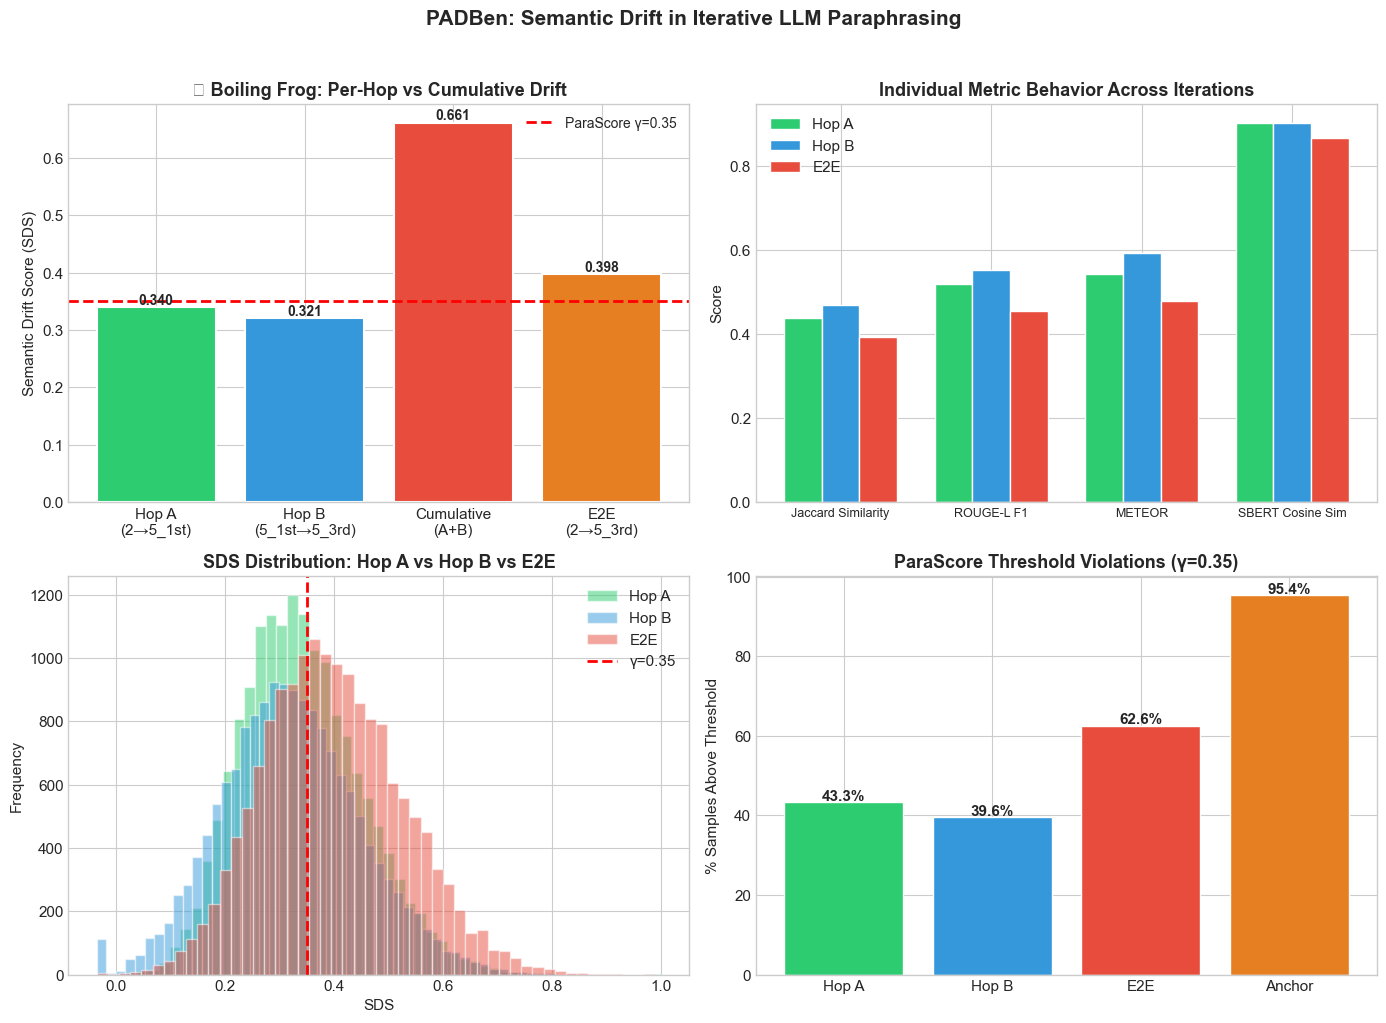

19:13:59 | INFO    | Saved: fig_boiling_frog_effect.png
INFO:boiling_frog:Saved: fig_boiling_frog_effect.png


In [22]:
# ============================================================================
# 7C: FIGURE — Boiling Frog Effect Visualization (publication-ready)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Cumulative Drift Bar Chart ---
ax = axes[0, 0]
stages = ['Hop A\n(2→5_1st)', 'Hop B\n(5_1st→5_3rd)', 'Cumulative\n(A+B)', 'E2E\n(2→5_3rd)']
values = [hop_a_mean, hop_b_mean, cumulative, e2e_mean]
colors_bar = ['#2ecc71', '#3498db', '#e74c3c', '#e67e22']
bars = ax.bar(stages, values, color=colors_bar, edgecolor='white', linewidth=1.5)
ax.axhline(y=CFG.parascore_threshold, color='red', linestyle='--', linewidth=2, label=f'ParaScore γ={CFG.parascore_threshold}')
ax.set_ylabel('Semantic Drift Score (SDS)', fontsize=11)
ax.set_title('🐸 Boiling Frog: Per-Hop vs Cumulative Drift', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# --- Plot 2: Individual Metric Comparison ---
ax = axes[0, 1]
x = np.arange(len(metric_names))
width = 0.25
for i, (hop_name, color, label) in enumerate([('hop_a', '#2ecc71', 'Hop A'), ('hop_b', '#3498db', 'Hop B'), ('e2e', '#e74c3c', 'E2E')]):
    vals = [df[f'{m}_{hop_name}'].mean() for m in metric_names]
    ax.bar(x + i*width, vals, width, label=label, color=color, edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels([metric_labels[m] for m in metric_names], fontsize=9)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Individual Metric Behavior Across Iterations', fontsize=13, fontweight='bold')
ax.legend()

# --- Plot 3: SDS Distribution per Hop ---
ax = axes[1, 0]
for hop_name, color, label in [('hop_a', '#2ecc71', 'Hop A'), ('hop_b', '#3498db', 'Hop B'), ('e2e', '#e74c3c', 'E2E')]:
    ax.hist(df[f'SDS_{hop_name}'], bins=50, alpha=0.5, color=color, label=label, edgecolor='white')
ax.axvline(x=CFG.parascore_threshold, color='red', linestyle='--', linewidth=2, label=f'γ={CFG.parascore_threshold}')
ax.set_xlabel('SDS', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('SDS Distribution: Hop A vs Hop B vs E2E', fontsize=13, fontweight='bold')
ax.legend()

# --- Plot 4: ParaScore Threshold Violation ---
ax = axes[1, 1]
pct_above = {
    'Hop A': (df['SDS_hop_a'] > CFG.parascore_threshold).mean() * 100,
    'Hop B': (df['SDS_hop_b'] > CFG.parascore_threshold).mean() * 100,
    'E2E': (df['SDS_e2e'] > CFG.parascore_threshold).mean() * 100,
    'Anchor': (df['SDS_anchor'] > CFG.parascore_threshold).mean() * 100,
}
bars = ax.bar(pct_above.keys(), pct_above.values(), color=['#2ecc71', '#3498db', '#e74c3c', '#e67e22'], edgecolor='white')
ax.set_ylabel('% Samples Above Threshold', fontsize=11)
ax.set_title(f'ParaScore Threshold Violations (γ={CFG.parascore_threshold})', fontsize=13, fontweight='bold')
for bar, val in zip(bars, pct_above.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

fig.suptitle('PADBen: Semantic Drift in Iterative LLM Paraphrasing', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_boiling_frog_effect.png', dpi=200, bbox_inches='tight')
plt.show()
log.info("Saved: fig_boiling_frog_effect.png")

Spearman Correlation Matrix (E2E):
           Jaccard  ROUGE-L  METEOR  SBERT Cos  Edit Dist    SDS
Jaccard      1.000    0.752   0.902      0.646     -0.444 -0.840
ROUGE-L      0.752    1.000   0.807      0.535     -0.771 -0.808
METEOR       0.902    0.807   1.000      0.619     -0.508 -0.867
SBERT Cos    0.646    0.535   0.619      1.000     -0.364 -0.902
Edit Dist   -0.444   -0.771  -0.508     -0.364      1.000  0.561
SDS         -0.840   -0.808  -0.867     -0.902      0.561  1.000

Exported to ./outputs/spearman_correlation_matrix.csv


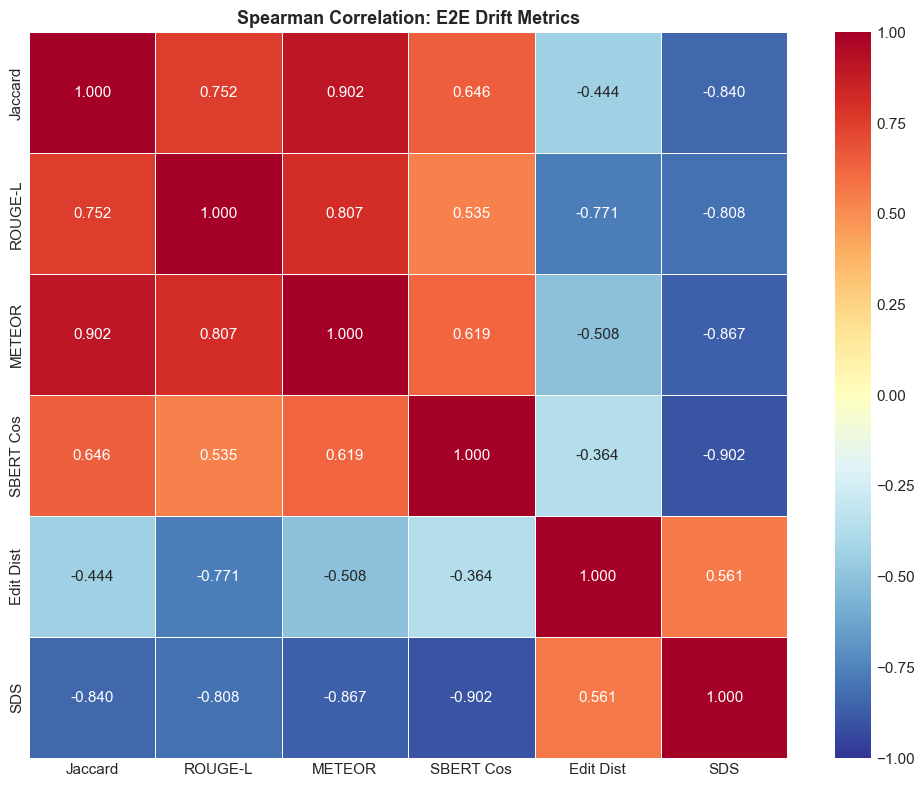

In [23]:
# ============================================================================
# 7D: CORRELATION HEATMAP — Metric Inter-relationships
# ============================================================================
corr_cols = [f'{m}_e2e' for m in ['jaccard', 'rouge_l', 'meteor', 'sbert_cosine', 'edit_dist']] + ['SDS_e2e']
corr_matrix = df[corr_cols].corr(method='spearman')

corr_matrix_labeled = corr_matrix.copy()
corr_matrix_labeled.index = ['Jaccard', 'ROUGE-L', 'METEOR', 'SBERT Cos', 'Edit Dist', 'SDS']
corr_matrix_labeled.columns = corr_matrix_labeled.index
corr_matrix_labeled.to_csv(Path(CFG.output_dir) / 'spearman_correlation_matrix.csv')
print("Spearman Correlation Matrix (E2E):")
print(corr_matrix_labeled.round(3).to_string())
print(f"\nExported to {CFG.output_dir}/spearman_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(10, 8))
labels = ['Jaccard', 'ROUGE-L', 'METEOR', 'SBERT Cos', 'Edit Dist', 'SDS']
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=ax,
            xticklabels=labels, yticklabels=labels, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Spearman Correlation: E2E Drift Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8: Export & Reproducibility

In [24]:
# ============================================================================
# 7E: APPENDIX A — Standard Deviation Values for Table 2
# ============================================================================
# Full hop-by-hop and cumulative standard deviation values for the paper appendix.
# ============================================================================

print("=" * 70)
print("APPENDIX A: Standard Deviation Values for Table 2 (PADBEN)")
print("=" * 70)

hop_names = ['hop_a', 'hop_b', 'e2e', 'anchor']
hop_labels = {
    'hop_a': 'Hop A (T2 -> T5-1st)',
    'hop_b': 'Hop B (T5-1st -> T5-3rd)',
    'e2e': 'End-to-End (T2 -> T5-3rd)',
    'anchor': 'Anchor (T1 -> T5-3rd)',
}

appendix_rows = []
for h in hop_names:
    col = f'SDS_{h}'
    appendix_rows.append({
        'Measurement': hop_labels[h],
        'Mean SDS': round(df[col].mean(), 4),
        'Std Dev': round(df[col].std(), 4),
        'Min': round(df[col].min(), 4),
        'Median': round(df[col].median(), 4),
        'Max': round(df[col].max(), 4),
    })

cumulative_per_record = df['SDS_hop_a'] + df['SDS_hop_b']
appendix_rows.append({
    'Measurement': 'Path Length L (A+B)',
    'Mean SDS': round(cumulative_per_record.mean(), 4),
    'Std Dev': round(cumulative_per_record.std(), 4),
    'Min': round(cumulative_per_record.min(), 4),
    'Median': round(cumulative_per_record.median(), 4),
    'Max': round(cumulative_per_record.max(), 4),
})

appendix_df = pd.DataFrame(appendix_rows)
appendix_df.to_csv(Path(CFG.output_dir) / 'appendix_a_stddev_table2.csv', index=False)
print()
print(appendix_df.to_string(index=False))
print(f"\nExported to {CFG.output_dir}/appendix_a_stddev_table2.csv")

APPENDIX A: Standard Deviation Values for Table 2 (PADBEN)

              Measurement  Mean SDS  Std Dev     Min  Median    Max
     Hop A (T2 -> T5-1st)    0.3403   0.1104  0.0202  0.3312 1.0000
 Hop B (T5-1st -> T5-3rd)    0.3210   0.1289 -0.0350  0.3163 0.8425
End-to-End (T2 -> T5-3rd)    0.3979   0.1284 -0.0350  0.3901 0.9890
    Anchor (T1 -> T5-3rd)    0.5914   0.1366  0.0592  0.5980 1.0126
      Path Length L (A+B)    0.6613   0.2071  0.0093  0.6471 1.7102

Exported to ./outputs/appendix_a_stddev_table2.csv


In [25]:
# ============================================================================
# 8A: EXPORT RESULTS
# ============================================================================
pipeline_elapsed = time.time() - pipeline_start

# CSV export
export_cols = ['idx', 'dataset_source'] + \
    [f'{m}_{h}' for h in ['hop_a', 'hop_b', 'e2e', 'anchor'] for m in ['jaccard', 'rouge_l', 'meteor', 'sbert_cosine', 'sbert_euclid', 'edit_dist']] + \
    [f'SDS_{h}' for h in ['hop_a', 'hop_b', 'e2e', 'anchor']]

df[export_cols].to_csv(Path(CFG.output_dir) / 'drift_results.csv', index=False)
log.info("Exported: drift_results.csv")

# JSON summary
summary = {
    'pipeline_version': '2.0-DE',
    'run_timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
    'runtime_seconds': round(pipeline_elapsed, 1),
    'data_fingerprint': data_hash,
    'config': asdict(CFG),
    'dataset': {
        'total_records': len(df),
        'sources': df['dataset_source'].value_counts().to_dict()
    },
    'validation': {
        'valid': len(valid_records),
        'invalid': len(invalid_records)
    },
    'results': {
        'SDS_hop_a_mean': round(df['SDS_hop_a'].mean(), 4),
        'SDS_hop_b_mean': round(df['SDS_hop_b'].mean(), 4),
        'SDS_e2e_mean': round(df['SDS_e2e'].mean(), 4),
        'SDS_anchor_mean': round(df['SDS_anchor'].mean(), 4),
        'cumulative_additive': round(df['SDS_hop_a'].mean() + df['SDS_hop_b'].mean(), 4),
        'parascore_threshold': CFG.parascore_threshold,
        'pct_above_threshold_hop_a': round((df['SDS_hop_a'] > CFG.parascore_threshold).mean() * 100, 2),
        'pct_above_threshold_e2e': round((df['SDS_e2e'] > CFG.parascore_threshold).mean() * 100, 2),
        'boiling_frog_multiplier': round((df['SDS_hop_a'].mean() + df['SDS_hop_b'].mean()) / CFG.parascore_threshold, 2)
    },
    'individual_metrics_e2e': {
        m: round(df[f'{m}_e2e'].mean(), 4)
        for m in ['jaccard', 'rouge_l', 'meteor', 'sbert_cosine', 'edit_dist']
    }
}

with open(Path(CFG.output_dir) / 'pipeline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
log.info("Exported: pipeline_summary.json")

# Final report
print(f"\n{'='*60}")
print("🏁 PIPELINE COMPLETE")
print(f"{'='*60}")
print(f"   Runtime:     {pipeline_elapsed:.1f}s ({pipeline_elapsed/60:.1f} min)")
print(f"   Records:     {len(df):,}")
print(f"   Outputs:     {CFG.output_dir}/")
print(f"   Cache:       {CFG.cache_dir}/")
print(f"   Logs:        {CFG.log_dir}/")
print("\n   📊 Key Findings:")
print(f"      Hop A SDS:       {df['SDS_hop_a'].mean():.4f}")
print(f"      Hop B SDS:       {df['SDS_hop_b'].mean():.4f}")
print(f"      Cumulative SDS:  {df['SDS_hop_a'].mean() + df['SDS_hop_b'].mean():.4f}")
print(f"      E2E SDS:         {df['SDS_e2e'].mean():.4f}")
print(f"      Threshold mult:  {(df['SDS_hop_a'].mean() + df['SDS_hop_b'].mean()) / CFG.parascore_threshold:.1f}×")

19:14:00 | INFO    | Exported: drift_results.csv
INFO:boiling_frog:Exported: drift_results.csv
19:14:00 | INFO    | Exported: pipeline_summary.json
INFO:boiling_frog:Exported: pipeline_summary.json



🏁 PIPELINE COMPLETE
   Runtime:     74.4s (1.2 min)
   Records:     16,232
   Outputs:     ./outputs/
   Cache:       ./cache/
   Logs:        ./logs/

   📊 Key Findings:
      Hop A SDS:       0.3403
      Hop B SDS:       0.3210
      Cumulative SDS:  0.6613
      E2E SDS:         0.3979
      Threshold mult:  1.9×


In [26]:
# ============================================================================
# 8B: ENVIRONMENT WATERMARK
# ============================================================================
try:
    %load_ext watermark
    %watermark -d -u -v -iv -b -h -m --gpu
except:
    print(f"Python: {sys.version}")
    print(f"PyTorch: {torch.__version__}")
    print(f"Device: {DEVICE}")
    print(f"NumPy: {np.__version__}")
    print(f"Pandas: {pd.__version__}")

Last updated: 2026-03-30

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.1.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 191 Stepping 2, GenuineIntel
CPU cores   : 24
Architecture: 64bit

Hostname: [REDACTED]

Git branch: main

Levenshtein          : 0.27.3
bert_score           : 0.3.13
ftfy                 : 6.3.1
json                 : 2.0.9
logging              : 0.5.1.2
matplotlib           : 3.10.6
nltk                 : 3.9.1
numpy                : 2.1.3
pandas               : 2.2.3
pydantic             : 2.12.5
re                   : 2.2.1
rouge_score          : 0.1.2
scipy                : 1.16.1
seaborn              : 0.13.2
sentence_transformers: 5.2.2
sklearn              : 1.7.2
torch                : 2.8.0+cu129
tqdm                 : 4.67.1

GPU Info: Install the gpu extra (pip install "watermark[gpu]") to display GPU information for NVIDIA c

---
## 🏁 Pipeline Outputs

### Data Files

| File | Description |
|------|-------------|
| `outputs/drift_results.csv` | Full drift metrics (Jaccard, ROUGE-L, METEOR, SBERT, Edit Distance, SDS) across all hops for 16K+ records |
| `outputs/pipeline_summary.json` | Run metadata, config, timing, and key statistical findings |
| `outputs/data_quality_report.csv` | Per-column quality assessment (completeness, duplicates, token stats, encoding issues) |
| `outputs/extreme_drift_cases.csv` | Records exhibiting extreme semantic drift (low SBERT cosine similarity) |
| `outputs/generation_artifacts.csv` | Records flagged as LLM generation artifacts (e.g., language switches, hallucinations) |
| `logs/pipeline_*.log` | Timestamped execution log with all pipeline steps |
| `cache/emb_*.npy` | Cached SBERT embeddings (skips recomputation) |

### Figures

| File | Description |
|------|-------------|
| `outputs/fig_boiling_frog_effect.png` | Publication-ready 4-panel figure: per-hop vs cumulative SDS, individual metric behavior, SDS distributions, and ParaScore threshold violations |
| `outputs/fig_correlation_heatmap.png` | Spearman correlation matrix across all E2E drift metrics (Jaccard, ROUGE-L, METEOR, SBERT Cos, Edit Dist, SDS) |
| `outputs/fig_extreme_drift_discovery.png` | Cosine similarity distributions across hops and bar chart of negative-cosine cases growing with iterations |
| `outputs/fig_artifact_classification.png` | Generation artifact detection: zero-overlap classification, dual-criteria classification, and anchor cosine distribution |
| `outputs/fig_source_distribution.png` | Records by dataset source (PAWS, MRPC, HLPC) with counts and percentages |
| `outputs/fig_token_distributions.png` | Token length distributions per text type (Human Original, LLM Generated, Human Paraphrased, LLM Paraphrased, LLM Iter-1, LLM Iter-3) |